# Reliability Study Summary Analysis

This notebook generates summary visualizations from:
- cross_split_metrics.csv (Dice, Jaccard, relative_diff per model/subject)
- image_quality_metrics.csv (SNR, CNR per subject)

Run each cell in order in your Jupyter notebook.



In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Load data and strip whitespace from column names AND string values
reliability_df = pd.read_csv("../data/cross_split_metrics.csv")

quality_df = pd.read_csv("../data/image_quality_metrics.csv")

infodump_df = pd.read_csv("../data/raw_subject_data.csv")

subjects_df = pd.read_csv("../data/subject.csv")

split_pair_diffs = pd.read_csv("../data/split_comparision_data.csv")

In [3]:
# Cell 1a Data access functions (LEAVE COLLAPSED)
def get_split_data(quality_df, subject_id, session_id, split):
    """
    Get data for a specific subject and split.

    Parameters:
    -----------
    quality_df : pd.DataFrame
        Long-format dataframe with columns: subject_id, session_id, split, ...
    subject_id : str
        Subject identifier
    split : str
        Split name (S1, S2, S3, S4)

    Returns:
    --------
    pd.Series or None if not found
    """
    mask = (
        (quality_df["subject_id"].astype(str) == str(subject_id))
        & (quality_df["split"] == split)
        & (quality_df["session_id"] == session_id)
    )
    result = quality_df[mask]
    return result.iloc[0] if len(result) > 0 else None


def _compute_split_pair_diff(quality_df, column, split1, split2, relative=True):
    """
    Compute difference between two splits for a given column.
    Uses subject_id + session_id as unique identifier to handle subjects with multiple sessions.
    """
    # Get data for each split
    s1_df = quality_df[quality_df["split"] == split1][
        ["subject_id", "session_id", column]
    ].copy()
    s2_df = quality_df[quality_df["split"] == split2][
        ["subject_id", "session_id", column]
    ].copy()

    # Rename columns for merge
    s1_df = s1_df.rename(columns={column: "val1"})
    s2_df = s2_df.rename(columns={column: "val2"})

    # Merge on subject_id AND session_id to handle subjects with multiple sessions
    result = s1_df.merge(s2_df, on=["subject_id", "session_id"], how="inner")

    # Create a display label (subject_id only, for cleaner plot labels)
    result["label"] = result["subject_id"].astype(str)

    # Compute difference
    if relative:
        mean_val = (result["val1"] + result["val2"]) / 2
        result["diff"] = abs(result["val1"] - result["val2"]) / mean_val * 100
    else:
        result["diff"] = abs(result["val1"] - result["val2"])

    return result


def get_column_by_split(quality_df, column, split):
    """
    Get a column's values for all subjects at a specific split.

    Parameters:
    -----------
    quality_df : pd.DataFrame
        Long-format dataframe
    column : str
        Column name (e.g., 'native_vol_sp', 'snr_subplate')
    split : str
        Split name (S1, S2, S3, S4)

    Returns:
    --------
    pd.Series with subject_id as index
    """
    split_data = quality_df[quality_df["split"] == split].copy()
    split_data = split_data.set_index("subject_id")
    if column in split_data.columns:
        return split_data[column]
    return pd.Series(dtype=float)


def get_subject_across_splits(quality_df, subject_id, columns=None):
    """
    Get all split data for a single subject, pivoted to wide format.

    Parameters:
    -----------
    quality_df : pd.DataFrame
        Long-format dataframe
    subject_id : str
        Subject identifier
    columns : list or None
        Specific columns to include (None = all)

    Returns:
    --------
    dict with split names as keys, containing the row data
    """
    subject_data = quality_df[quality_df["subject_id"].astype(str) == str(subject_id)]
    result = {}
    for _, row in subject_data.iterrows():
        split = row["split"]
        if columns:
            result[split] = {col: row[col] for col in columns if col in row.index}
        else:
            result[split] = row.to_dict()
    return result


def get_unique_subjects(quality_df):
    """Get list of unique subjects (subject_id, session_id) as tuples."""
    return list(quality_df[["subject_id", "session_id"]].drop_duplicates().itertuples(index=False, name=None))


def get_available_splits(quality_df):
    """Get list of available splits in the data."""
    return sorted(quality_df["split"].unique())

In [4]:
# Cell 1b Summary

print(f"Subjects found: {subjects_df['subject_id'].nunique()} subjects")
print(
    f"Reliability data: {len(reliability_df)} rows, {reliability_df['subject_id'].nunique()} subjects"
)
print(
    f"Quality data: {len(quality_df)} rows, {quality_df['subject_id'].nunique()} subjects"
)
print(f"  Splits available: {get_available_splits(quality_df)}")
print(f"Infodump data: {infodump_df['subject_id'].nunique()} subjects")
print(f"\nModels in reliability data: {reliability_df['model'].unique().tolist()}")

# Show quality_df columns for reference
print(f"\nQuality metrics columns:")
print(f"  {quality_df.columns.tolist()}")

print(f"\nSubjects columns :")
print(f"  {subjects_df.columns.tolist()}")

Subjects found: 23 subjects
Reliability data: 414 rows, 23 subjects
Quality data: 92 rows, 23 subjects
  Splits available: ['S1', 'S2', 'S3', 'S4']
Infodump data: 23 subjects

Models in reliability data: ['SP Model - Cortical Plate', 'SP Model - Subplate', '5-Label Model - Cortical Plate']

Quality metrics columns:
  ['subject_id', 'session_id', 'GA', 'split', 'snr_subplate', 'snr_cortical_plate', 'snr_inner', 'cnr_sp_cp', 'cnr_sp_inner', 'cnr_cp_inner', 'sp_mean_intensity', 'sp_std_intensity', 'sp_volume_voxels', 'cp_mean_intensity', 'cp_std_intensity', 'cp_volume_voxels', 'inner_mean_intensity', 'inner_std_intensity', 'inner_volume_voxels', 'scaling_factor', 'native_vol_sp', 'native_vol_cp', 'native_vol_inner']

Subjects columns :
  ['subject_id', 'session_id', 'GA']


/tmp/ipykernel_3028733/2219762970.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  subject_cmap = plt.cm.get_cmap("tab20", n_subjects)


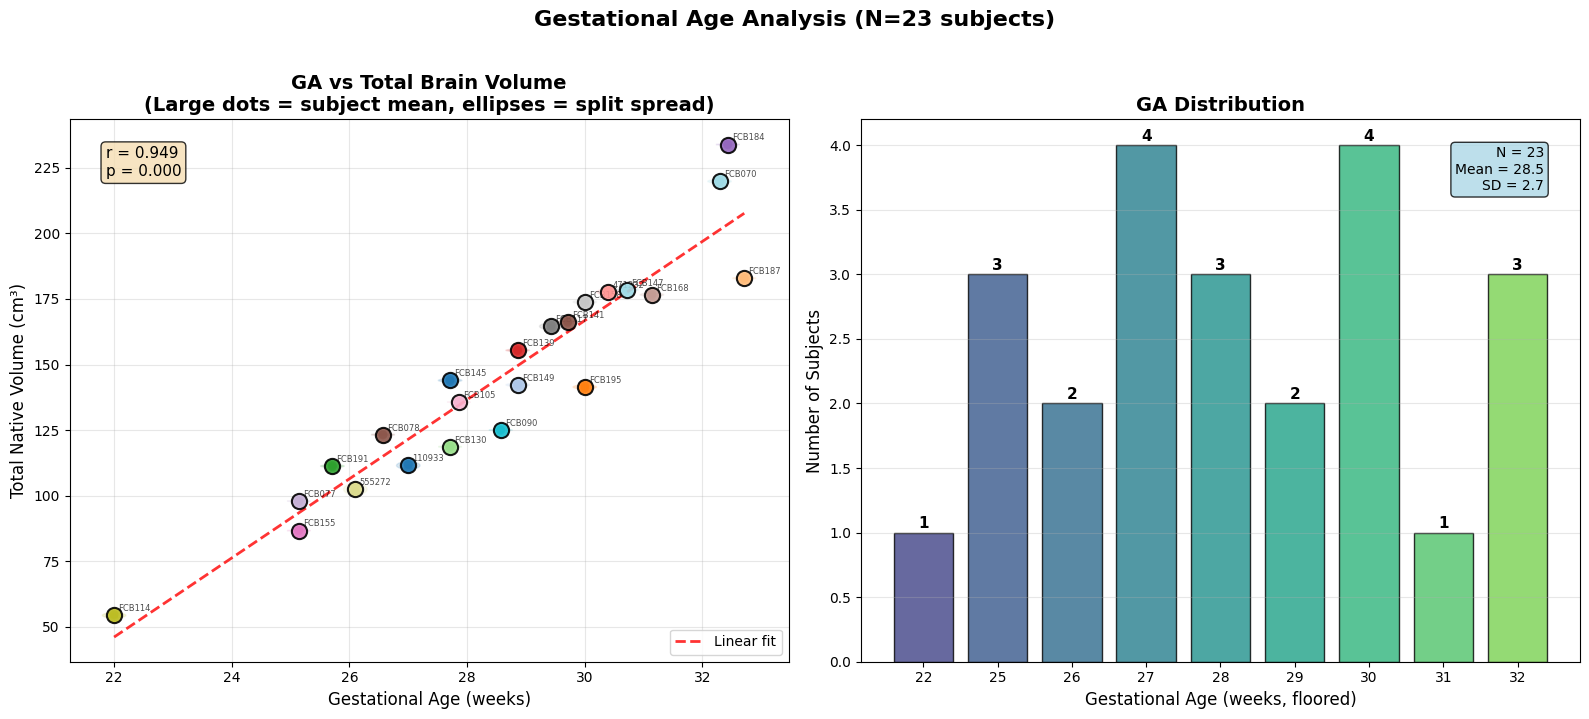

In [5]:
# 1c. GA Distribution: Scatter Plot and Bar Plot Side by Side
def plot_ga_distribution(quality_df):
    """
    Side-by-side scatter plot (GA vs Total Native Volume) and bar plot (GA distribution).
    GA values are floored and grouped by whole numbers.

    Parameters:
    -----------
    quality_df : pd.DataFrame
        Long-format dataframe with native volume metrics and GA
    """
    quality_df = quality_df.copy()
    quality_df["subject_id"] = quality_df["subject_id"].astype(str)
    quality_df["session_id"] = quality_df["session_id"].astype(str)

    # Floor GA values to whole numbers
    quality_df["GA_floored"] = np.floor(quality_df["GA"]).astype(int)

    # Compute total native volume (sum of SP + CP + Inner)
    quality_df["total_native_vol"] = (
        (quality_df["native_vol_sp"]
        + quality_df["native_vol_cp"]
        + quality_df["native_vol_inner"]) / 1000 #<- mm^3 to cm^3
    )

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # === Left: Scatter Plot (GA vs Total Native Volume) ===
    ax1 = axes[0]

    # Get unique subjects for color mapping
    unique_subjects = quality_df["subject_id"].unique()
    n_subjects = len(unique_subjects)
    subject_cmap = plt.cm.get_cmap("tab20", n_subjects)
    subject_colors = {subj: subject_cmap(i) for i, subj in enumerate(unique_subjects)}

    # Group by subject_id and session_id to plot 4 splits together
    grouped = quality_df.groupby(["subject_id", "session_id"])

    for (subj_id, sess_id), group in grouped:
        color = subject_colors[subj_id]
        ga_values = group["GA"].values
        vol_values = group["total_native_vol"].values

        # Plot individual points with low alpha
        ax1.scatter(
            ga_values, vol_values, c=[color], s=40, alpha=0.4, edgecolors="none"
        )

        # Plot mean as a larger marker with edge
        mean_ga = ga_values.mean()
        mean_vol = vol_values.mean()
        ax1.scatter(
            mean_ga,
            mean_vol,
            c=[color],
            s=120,
            alpha=0.9,
            edgecolors="black",
            linewidths=1.5,
            zorder=5,
        )

        # Draw a convex hull or ellipse around the 4 splits
        if len(ga_values) >= 3:
            from matplotlib.patches import Ellipse

            # Calculate spread
            ga_std = ga_values.std() if ga_values.std() > 0 else 0.1
            vol_std = vol_values.std() if vol_values.std() > 0 else 100

            ellipse = Ellipse(
                (mean_ga, mean_vol),
                width=ga_std * 4,  # Cover ~2 std on each side
                height=vol_std * 4,
                alpha=0.15,
                facecolor=color,
                edgecolor=color,
                linewidth=1,
            )
            ax1.add_patch(ellipse)

        # Add subject label near mean
        ax1.annotate(
            subj_id[:6],
            (mean_ga, mean_vol),
            fontsize=6,
            alpha=0.7,
            xytext=(3, 3),
            textcoords="offset points",
        )

    ax1.set_xlabel("Gestational Age (weeks)", fontsize=12)
    ax1.set_ylabel("Total Native Volume (cm³)", fontsize=12)
    ax1.set_title(
        "GA vs Total Brain Volume\n(Large dots = subject mean, ellipses = split spread)",
        fontsize=14,
        fontweight="bold",
    )
    ax1.grid(True, alpha=0.3)

    # Add correlation using subject means
    subject_means = (
        quality_df.groupby(["subject_id", "session_id"])
        .agg({"GA": "mean", "total_native_vol": "mean"})
        .dropna()
    )

    if len(subject_means) >= 3:
        r, p = stats.pearsonr(subject_means["GA"], subject_means["total_native_vol"])
        ax1.text(
            0.05,
            0.95,
            f"r = {r:.3f}\np = {p:.3f}",
            transform=ax1.transAxes,
            fontsize=11,
            verticalalignment="top",
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
        )

        # Add regression line
        z = np.polyfit(subject_means["GA"], subject_means["total_native_vol"], 1)
        p_line = np.poly1d(z)
        x_line = np.linspace(subject_means["GA"].min(), subject_means["GA"].max(), 100)
        ax1.plot(
            x_line, p_line(x_line), "r--", alpha=0.8, linewidth=2, label="Linear fit"
        )
        ax1.legend(loc="lower right")

    # === Right: Bar Plot (GA Distribution) ===
    ax2 = axes[1]

    # Get unique subject/session combinations for GA distribution
    ga_unique = quality_df.groupby(["subject_id", "session_id"])["GA_floored"].first()
    ga_counts = ga_unique.value_counts().sort_index()
    ga_sorted = ga_counts.index.tolist()
    counts = ga_counts.values

    # Color bars by GA
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(ga_sorted)))

    bars = ax2.bar(
        [str(int(ga)) for ga in ga_sorted],
        counts,
        color=colors,
        edgecolor="black",
        alpha=0.8,
    )

    # Add count labels on bars
    for bar, count in zip(bars, counts):
        ax2.annotate(
            f"{count}",
            xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            fontsize=11,
            fontweight="bold",
        )

    ax2.set_xlabel("Gestational Age (weeks, floored)", fontsize=12)
    ax2.set_ylabel("Number of Subjects", fontsize=12)
    ax2.set_title("GA Distribution", fontsize=14, fontweight="bold")
    ax2.grid(True, alpha=0.3, axis="y")

    # Add summary statistics (unique subject/sessions)
    total_n = len(ga_unique)
    mean_ga = quality_df.groupby(["subject_id", "session_id"])["GA"].first().mean()
    std_ga = quality_df.groupby(["subject_id", "session_id"])["GA"].first().std()

    ax2.text(
        0.95,
        0.95,
        f"N = {total_n}\nMean = {mean_ga:.1f}\nSD = {std_ga:.1f}",
        transform=ax2.transAxes,
        fontsize=10,
        verticalalignment="top",
        horizontalalignment="right",
        bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.8),
    )

    plt.suptitle(
        f"Gestational Age Analysis (N={total_n} subjects)",
        fontsize=16,
        fontweight="bold",
        y=1.02,
    )

    plt.tight_layout()
    return fig


# Now only needs quality_df
fig = plot_ga_distribution(quality_df)
plt.show()

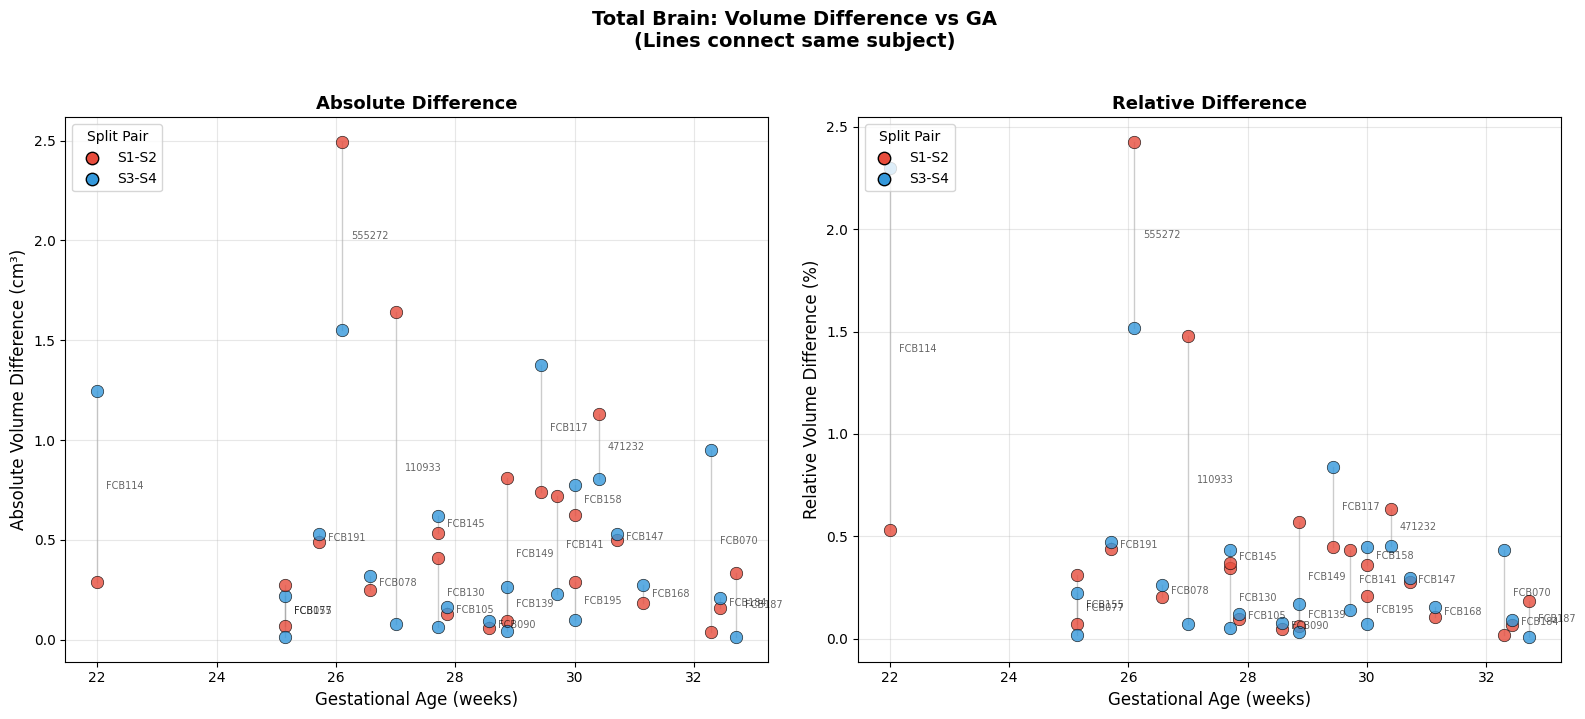

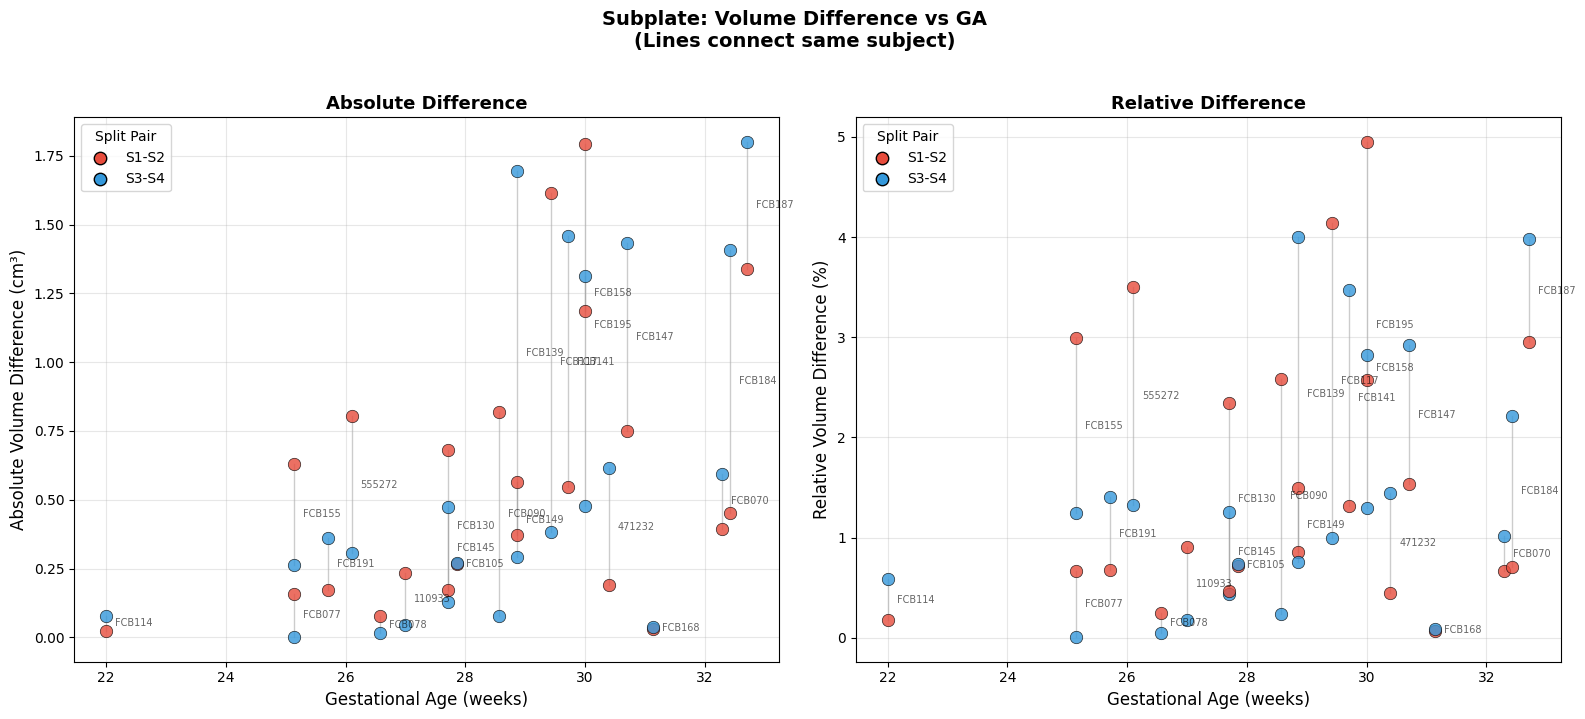

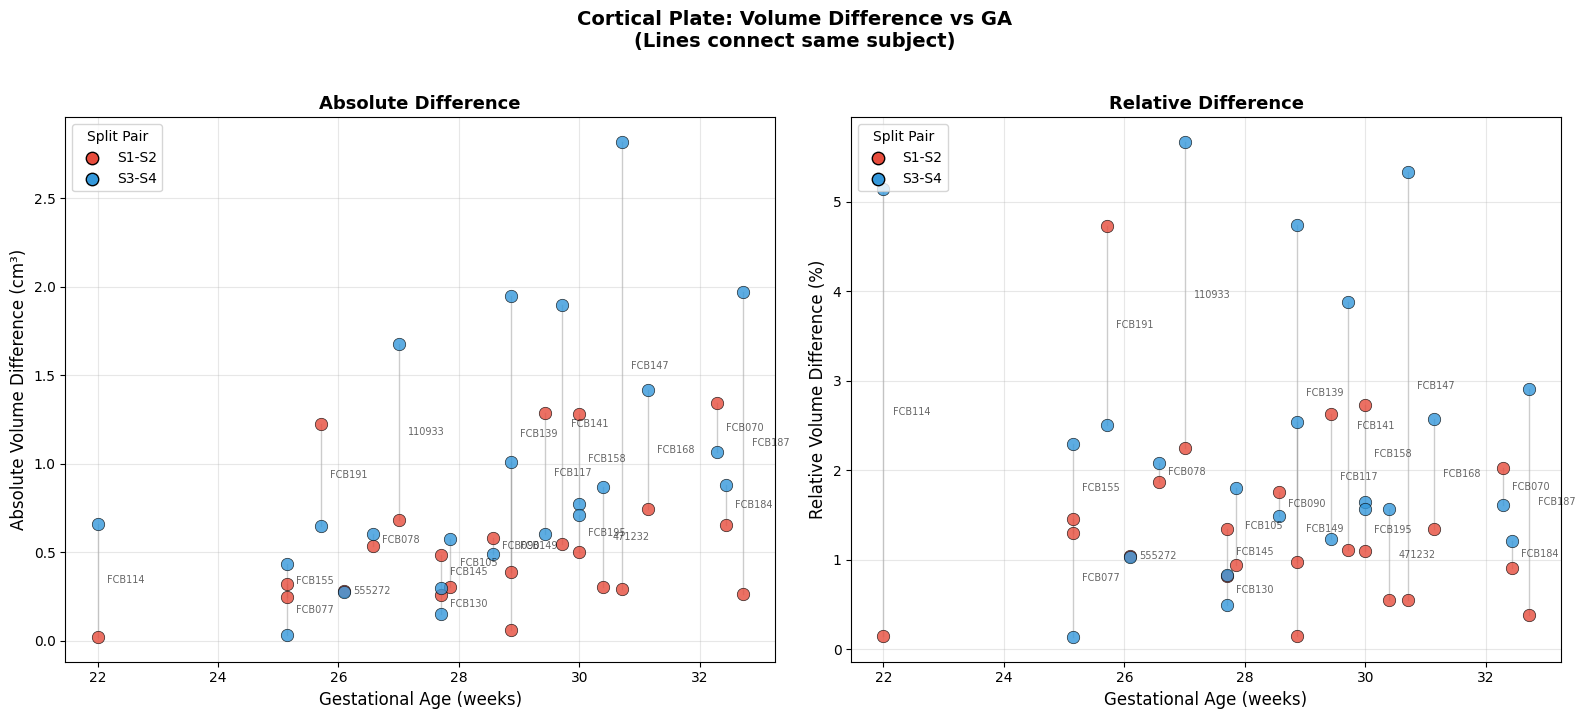

In [12]:
# SCATTER PLOT: Volume Difference vs GA (Absolute & Relative, Side by Side)
def plot_abs_and_rel_diff_vs_ga(split_pair_diffs, tissue="total", labels=True):
    """
    Side-by-side scatter plots: absolute and relative volume difference vs GA.
    """
    tissue_names = {
        "total": "Total Brain",
        "sp": "Subplate",
        "cp": "Cortical Plate",
        "inner": "Inner",
    }

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    colors = {"S1-S2": "#e74c3c", "S3-S4": "#3498db"}

    configs = [
        (axes[0], f"abs_diff_{tissue}", "cm³", 1000, "Absolute"),
        (axes[1], f"rel_diff_{tissue}", "%", 1, "Relative"),
    ]

    for ax, col, unit, scale, diff_type in configs:
        for (subj, sess), group in split_pair_diffs.groupby(
            ["subject_id", "session_id"]
        ):
            if len(group) < 2:
                continue

            ga = group["GA"].iloc[0]
            s12 = group[group["split_pair"] == "S1-S2"]
            s34 = group[group["split_pair"] == "S3-S4"]

            if len(s12) == 0 or len(s34) == 0:
                continue

            y12 = s12[col].values[0] / scale
            y34 = s34[col].values[0] / scale

            # Connect with gray line
            ax.plot(
                [ga, ga], [y12, y34], color="gray", alpha=0.4, linewidth=1, zorder=1
            )

            # Plot points
            ax.scatter(
                ga,
                y12,
                c=colors["S1-S2"],
                s=80,
                alpha=0.8,
                edgecolors="black",
                linewidths=0.5,
                zorder=2,
            )
            ax.scatter(
                ga,
                y34,
                c=colors["S3-S4"],
                s=80,
                alpha=0.8,
                edgecolors="black",
                linewidths=0.5,
                zorder=2,
            )

            # Subject label
            if labels:
                y_mid = (y12 + y34) / 2
                ax.text(ga + 0.15, y_mid, str(subj)[:6], fontsize=7, alpha=0.6, va="center")

        # Legend
        ax.scatter([], [], c=colors["S1-S2"], s=80, label="S1-S2", edgecolors="black")
        ax.scatter([], [], c=colors["S3-S4"], s=80, label="S3-S4", edgecolors="black")
        ax.legend(title="Split Pair", loc="upper left", fontsize=10)

        ax.set_xlabel("Gestational Age (weeks)", fontsize=12)
        ax.set_ylabel(f"{diff_type} Volume Difference ({unit})", fontsize=12)
        ax.set_title(f"{diff_type} Difference", fontsize=13, fontweight="bold")
        ax.grid(True, alpha=0.3)

    plt.suptitle(
        f"{tissue_names[tissue]}: Volume Difference vs GA\n(Lines connect same subject)",
        fontsize=14,
        fontweight="bold",
        y=1.02,
    )
    plt.tight_layout()
    return fig


# --- Run ---
fig = plot_abs_and_rel_diff_vs_ga(split_pair_diffs, tissue="total")
plt.show()

fig = plot_abs_and_rel_diff_vs_ga(split_pair_diffs, tissue="sp")
plt.show()

fig = plot_abs_and_rel_diff_vs_ga(split_pair_diffs, tissue="cp")
plt.show()

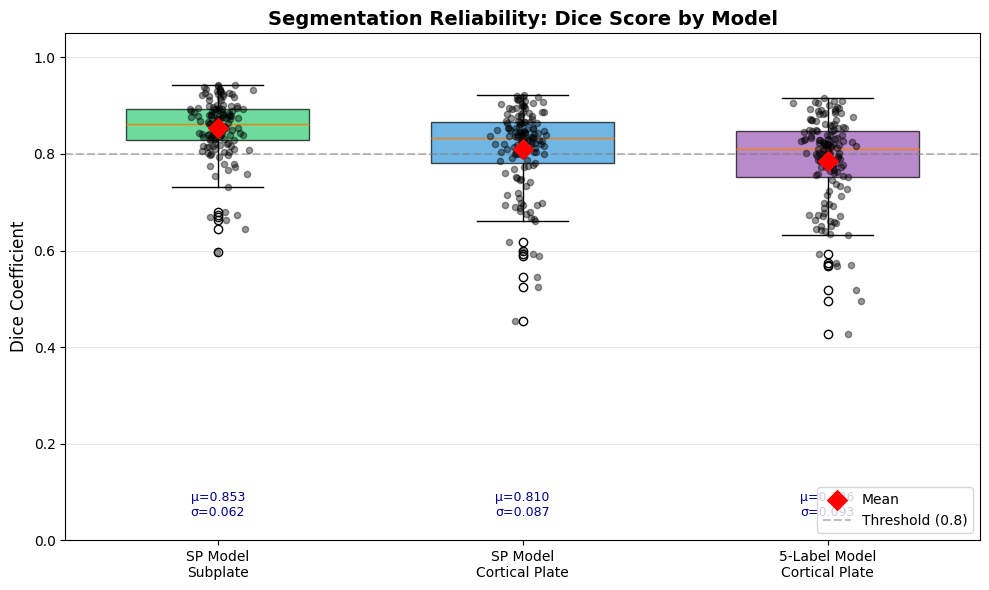

In [14]:
# 2a: Dice per model
def plot_dice_by_model(df):
    """Box plot comparing Dice scores across models."""
    fig, ax = plt.subplots(figsize=(10, 6))

    models = [
        "SP Model - Subplate",
        "SP Model - Cortical Plate",
        "5-Label Model - Cortical Plate",
    ]
    model_labels = [
        "SP Model\nSubplate",
        "SP Model\nCortical Plate",
        "5-Label Model\nCortical Plate",
    ]
    colors = ["#2ecc71", "#3498db", "#9b59b6"]

    data = [df[df["model"] == m]["dice"].values for m in models]

    bp = ax.boxplot(data, tick_labels=model_labels, patch_artist=True, widths=0.6)

    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    for i, d in enumerate(data):
        x = np.random.normal(i + 1, 0.04, size=len(d))
        ax.scatter(x, d, alpha=0.4, s=20, color="black", zorder=3)

    means = [np.mean(d) for d in data]
    ax.scatter(
        range(1, len(models) + 1),
        means,
        color="red",
        s=100,
        zorder=5,
        marker="D",
        label="Mean",
    )

    ax.set_ylabel("Dice Coefficient", fontsize=12)
    ax.set_title(
        "Segmentation Reliability: Dice Score by Model", fontsize=14, fontweight="bold"
    )
    ax.set_ylim(0, 1.05)
    ax.axhline(y=0.8, color="gray", linestyle="--", alpha=0.5, label="Threshold (0.8)")
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3, axis="y")

    for i, (m, d) in enumerate(zip(means, data)):
        ax.annotate(
            f"μ={m:.3f}\nσ={np.std(d):.3f}",
            xy=(i + 1, 0.05),
            ha="center",
            fontsize=9,
            color="darkblue",
        )

    plt.tight_layout()
    return fig


fig = plot_dice_by_model(reliability_df)
plt.show()

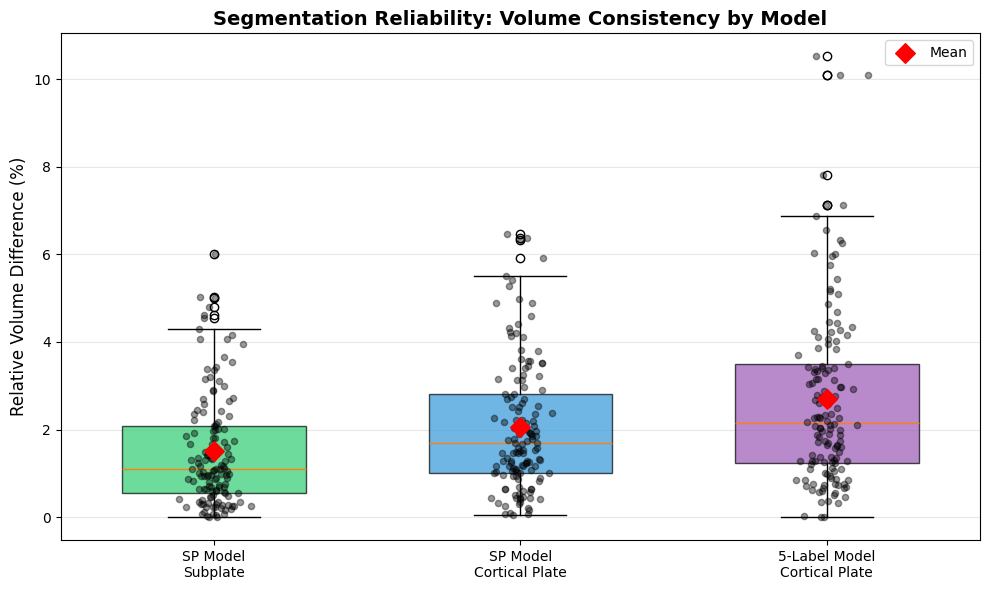

In [6]:
# 2a: relative diff per model (TODO: Change this to absolute difference CHECK NOTES)
def plot_relative_diff_by_model(df):
    """Box plot comparing relative volume difference across models."""
    fig, ax = plt.subplots(figsize=(10, 6))

    models = ['SP Model - Subplate', 'SP Model - Cortical Plate', '5-Label Model - Cortical Plate']
    model_labels = ['SP Model\nSubplate', 'SP Model\nCortical Plate', '5-Label Model\nCortical Plate']
    colors = ['#2ecc71', '#3498db', '#9b59b6']

    data = [df[df['model'] == m]['relative_diff'].values for m in models]

    bp = ax.boxplot(data, tick_labels=model_labels, patch_artist=True, widths=0.6)

    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    for i, d in enumerate(data):
        x = np.random.normal(i + 1, 0.04, size=len(d))
        ax.scatter(x, d, alpha=0.4, s=20, color='black', zorder=3)

    means = [np.mean(d) for d in data]
    ax.scatter(range(1, len(models) + 1), means, color='red', s=100, zorder=5, marker='D', label='Mean')

    ax.set_ylabel('Relative Volume Difference (%)', fontsize=12)
    ax.set_title('Segmentation Reliability: Volume Consistency by Model', fontsize=14, fontweight='bold')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    return fig

fig = plot_relative_diff_by_model(reliability_df)
plt.show()

/tmp/ipykernel_1392237/983874385.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  subject_cmap = plt.cm.get_cmap("tab20", n_subjects)


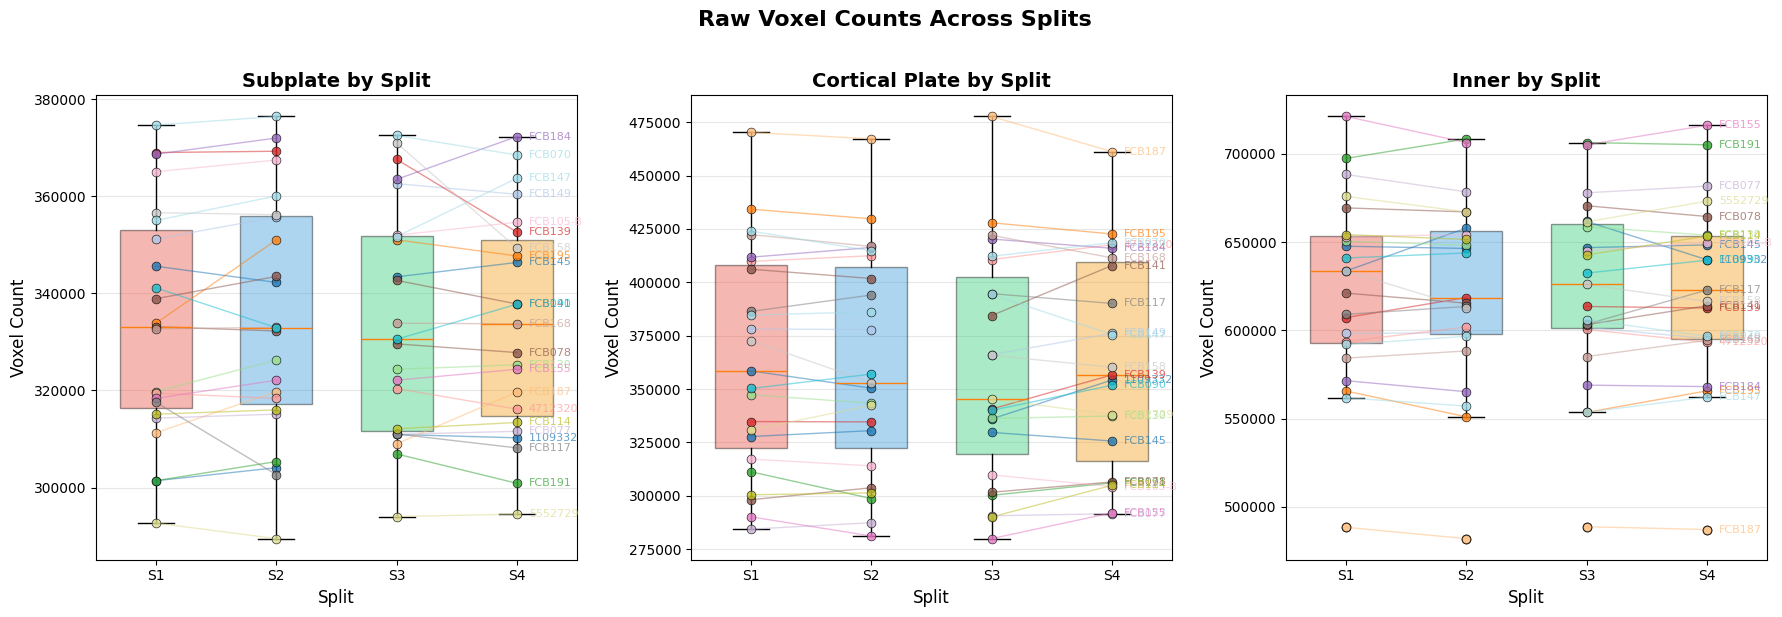

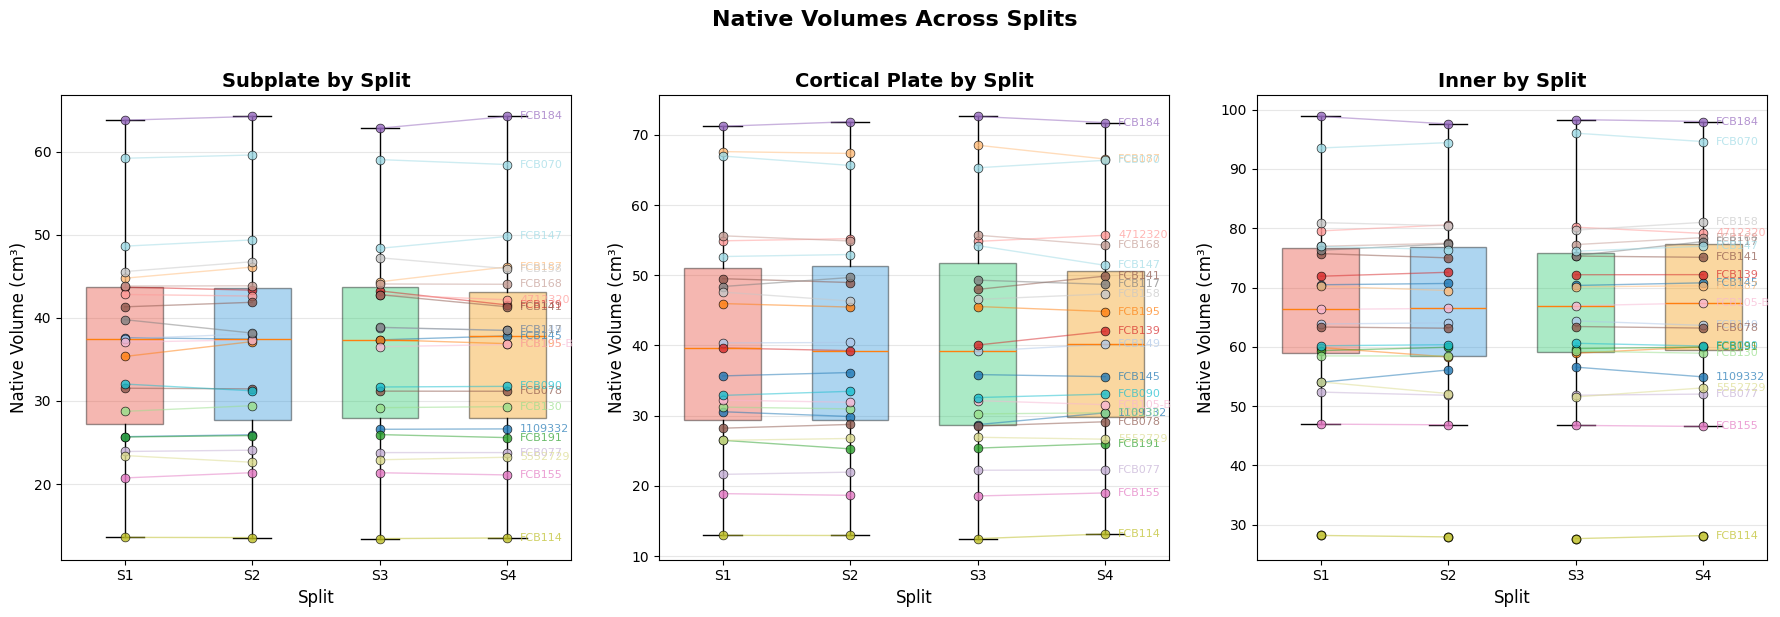

In [7]:
# 2a: Abs native volume diference across splits (subjects connected) TODO: Add subject identifier
def _get_subject_colors(quality_df):
    subjects = get_unique_subjects(quality_df)
    n_subjects = len(subjects)
    subject_cmap = plt.cm.get_cmap("tab20", n_subjects)
    subject_colors = {subj: subject_cmap(i) for i, subj in enumerate(subjects)}
    return subject_colors


def _plot_measures_across_splits(quality_df, measure_configs, subject_colors, title, ylabel, labels = False):
    """
    Internal helper to plot boxplots with connected subject lines across splits.

    Parameters:
    -----------
    quality_df : pd.DataFrame
        Long-format dataframe
    measure_configs : list of tuples
        Format: [(column_name, display_title), ...]
    title : str
        Super title for the figure
    ylabel : str
        Label for the y-axis
    """
    splits = get_available_splits(quality_df)
    subjects = get_unique_subjects(quality_df)

    # Distinct colors for boxes and subjects
    box_colors = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12"]

    n_plots = len(measure_configs)
    fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 6))
    if n_plots == 1:
        axes = [axes]  # Handle single plot case

    for ax, (col_name, display_name) in zip(axes, measure_configs):
        # 1. Prepare Boxplot Data (Aggregate per split)
        native = str(col_name).startswith("native") #<-Check if the col is a native value
        split_data = []
        for split in splits:
            # Use existing helper to get data for this split
            values = get_column_by_split(quality_df, col_name, split).dropna().values
            if native:
                values = values / 1000 #<- mm^3 to cm^3
            split_data.append(values)

        # 2. Draw Boxplot
        if any(len(d) > 0 for d in split_data):
            bp = ax.boxplot(
                split_data, tick_labels=splits, patch_artist=True, widths=0.6
            )
            for patch, color in zip(bp["boxes"], box_colors[: len(splits)]):
                patch.set_facecolor(color)
                patch.set_alpha(0.4)

        # 3. Draw Connected Lines per Subject
        for subj_id, ses_id in subjects:
            color = subject_colors[(subj_id, ses_id)]
            x_pos, y_val = [], []

            for i, split in enumerate(splits):
                # Use existing helper to get specific row for subject+split
                row = get_split_data(quality_df, subj_id, ses_id, split)

                # Check if row exists and column is valid/not-NaN
                if (
                    row is not None
                    and col_name in row.index
                    and pd.notna(row[col_name])
                ):
                    x_pos.append(i + 1)
                    if native:
                        y_val.append(row[col_name] / 1000)  # <- mm^3 to cm^3
                    else:
                        y_val.append(row[col_name]) 

            if x_pos:
                # Scatter points
                ax.scatter(
                    x_pos,
                    y_val,
                    color=color,
                    s=40,
                    alpha=0.8,
                    edgecolors="black",
                    linewidths=0.5,
                    zorder=3,
                )
                # Connected lines - only connect S1-S2 and S3-S4
                # Split into two groups: [S1, S2] and [S3, S4]
                for start_idx in [0, 2]:  # S1 at index 0, S3 at index 2
                    group_x = []
                    group_y = []
                    for j in range(len(x_pos)):
                        if x_pos[j] in [start_idx + 1, start_idx + 2]:  # S1-S2 or S3-S4
                            group_x.append(x_pos[j])
                            group_y.append(y_val[j])
                    if len(group_x) >= 2:
                        ax.plot(group_x, group_y, color=color, alpha=0.5, linewidth=1, zorder=2)
                
                # Add subject_id label to the right of the line
                if labels:
                    if len(x_pos) > 0:
                        ax.text(x_pos[-1] + 0.1, y_val[-1], f'{subj_id}', 
                            fontsize=8, va='center', ha='left', color=color, alpha=0.7)

        ax.set_ylabel(ylabel, fontsize=12)
        ax.set_xlabel("Split", fontsize=12)
        ax.set_title(f"{display_name} by Split", fontsize=14, fontweight="bold")
        ax.grid(True, alpha=0.3, axis="y")

    plt.suptitle(title, fontsize=16, fontweight="bold", y=1.02)
    plt.tight_layout()
    return fig


def plot_voxel_counts_by_split(quality_df, colors):
    """Plot raw voxel counts per split for SP and CP."""
    return _plot_measures_across_splits(
        quality_df,
        measure_configs=[
            ("sp_volume_voxels", "Subplate"),
            ("cp_volume_voxels", "Cortical Plate"),
            ("inner_volume_voxels", "Inner"),
        ],
        subject_colors=colors,
        title="Raw Voxel Counts Across Splits",
        ylabel="Voxel Count",
        labels=True
    )


def plot_native_volume_by_split(quality_df, colors):
    """Plot native volumes (mm³) per split for all tissues."""
    return _plot_measures_across_splits(
        quality_df,
        measure_configs=[
            ("native_vol_sp", "Subplate"),
            ("native_vol_cp", "Cortical Plate"),
            ("native_vol_inner", "Inner"),
        ],
        subject_colors=colors,
        title="Native Volumes Across Splits",
        ylabel="Native Volume (cm³)",
        labels=True
    )

colors = _get_subject_colors(quality_df)

fig1 = plot_voxel_counts_by_split(quality_df, colors)
plt.show()

fig2 = plot_native_volume_by_split(quality_df, colors)
plt.show()

 NATIVE VOLUMES


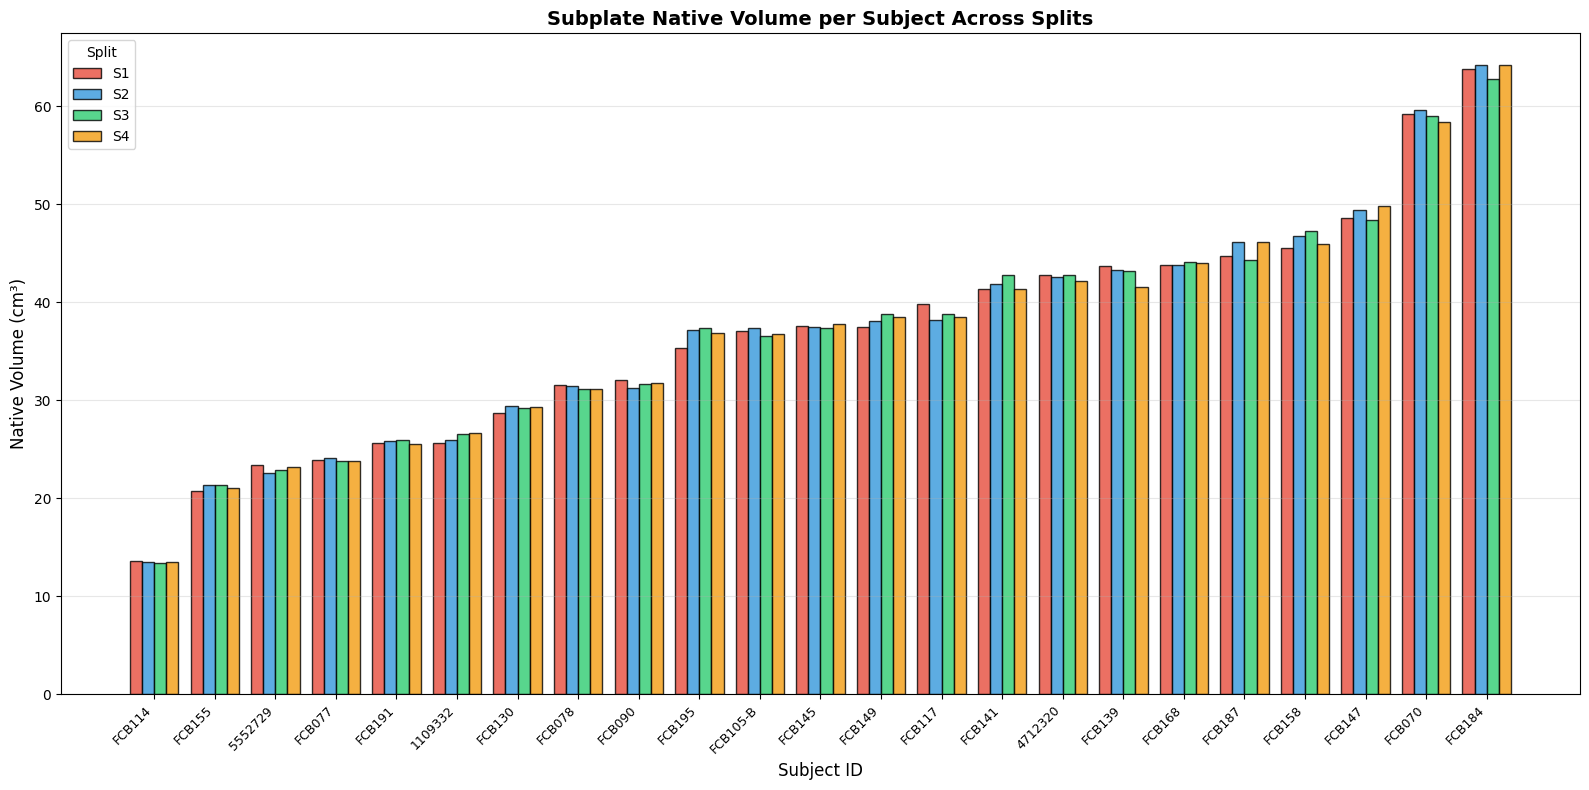

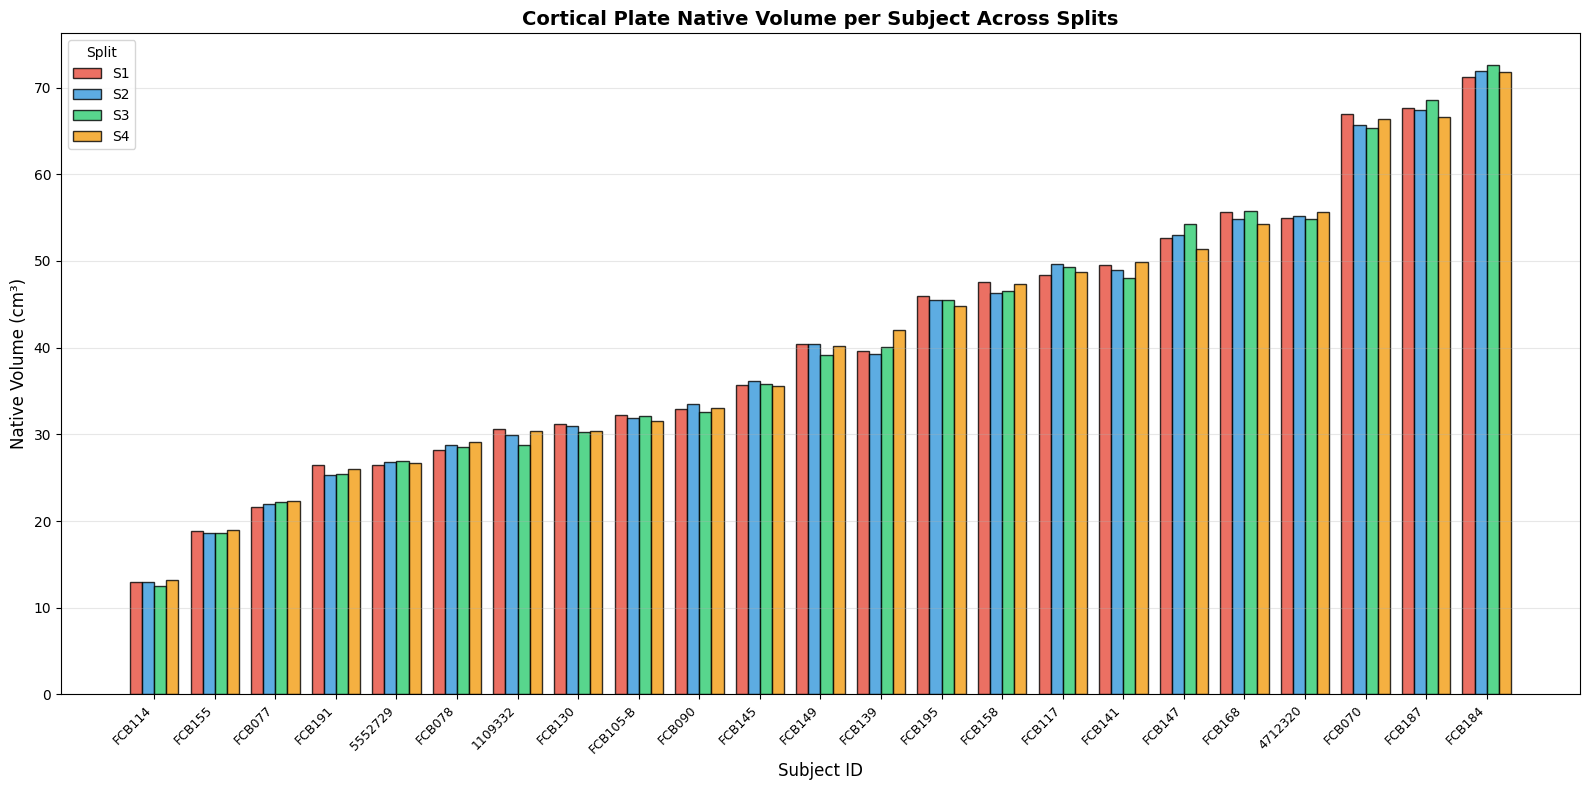

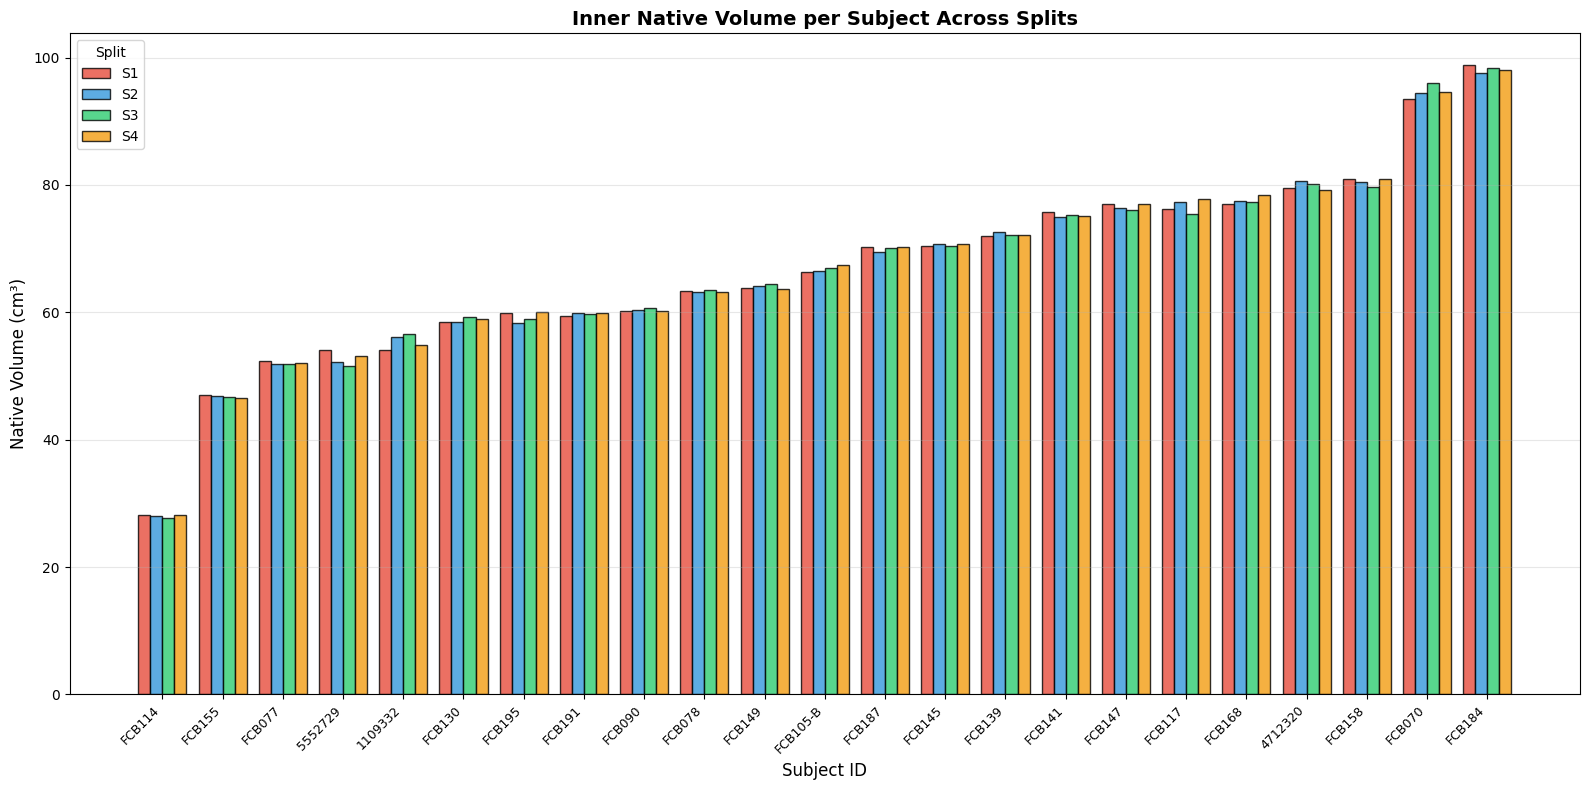

 VOXEL COUNTS 


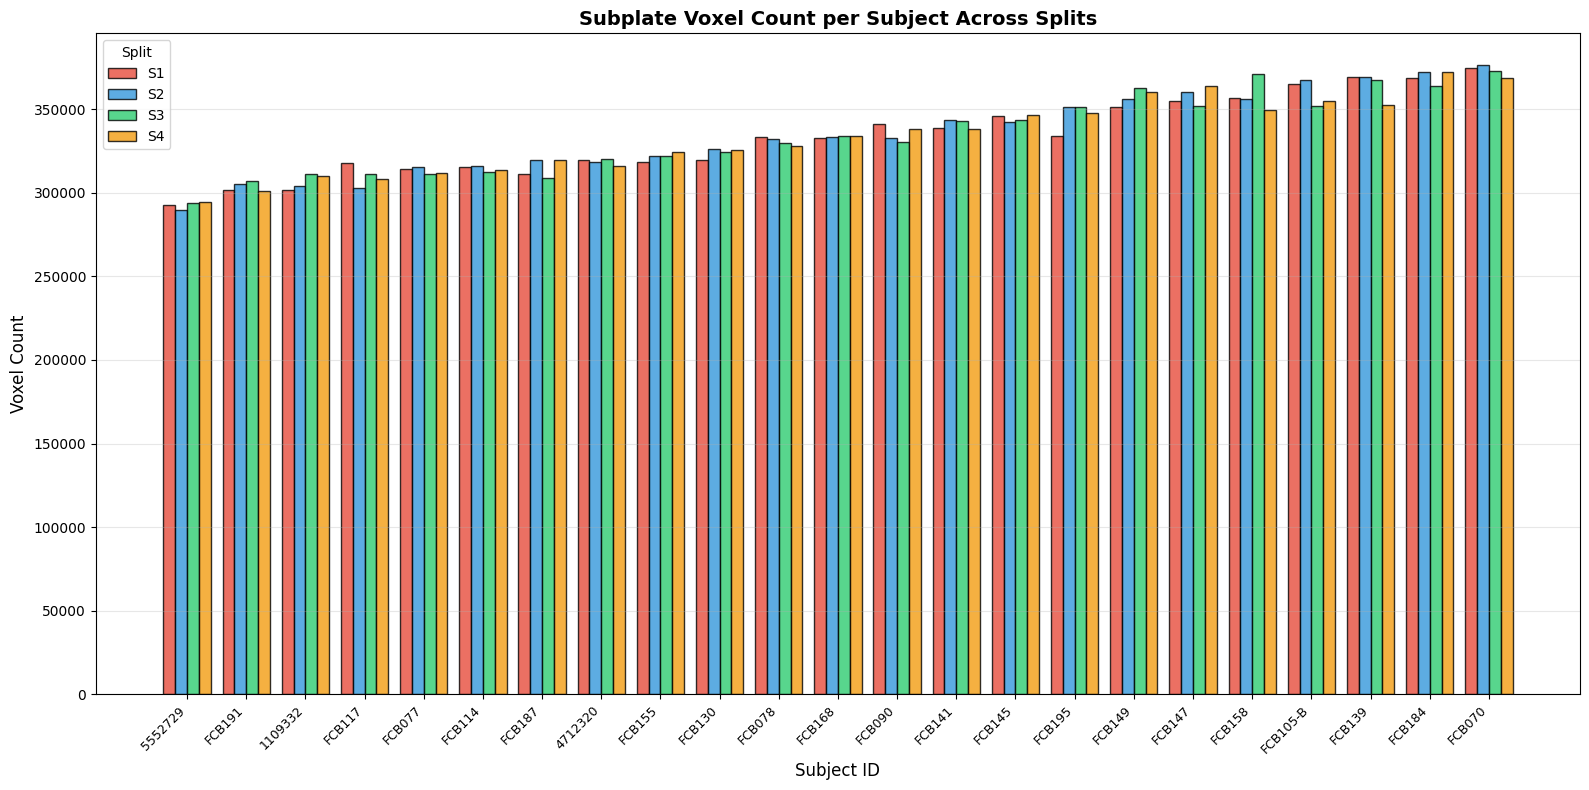

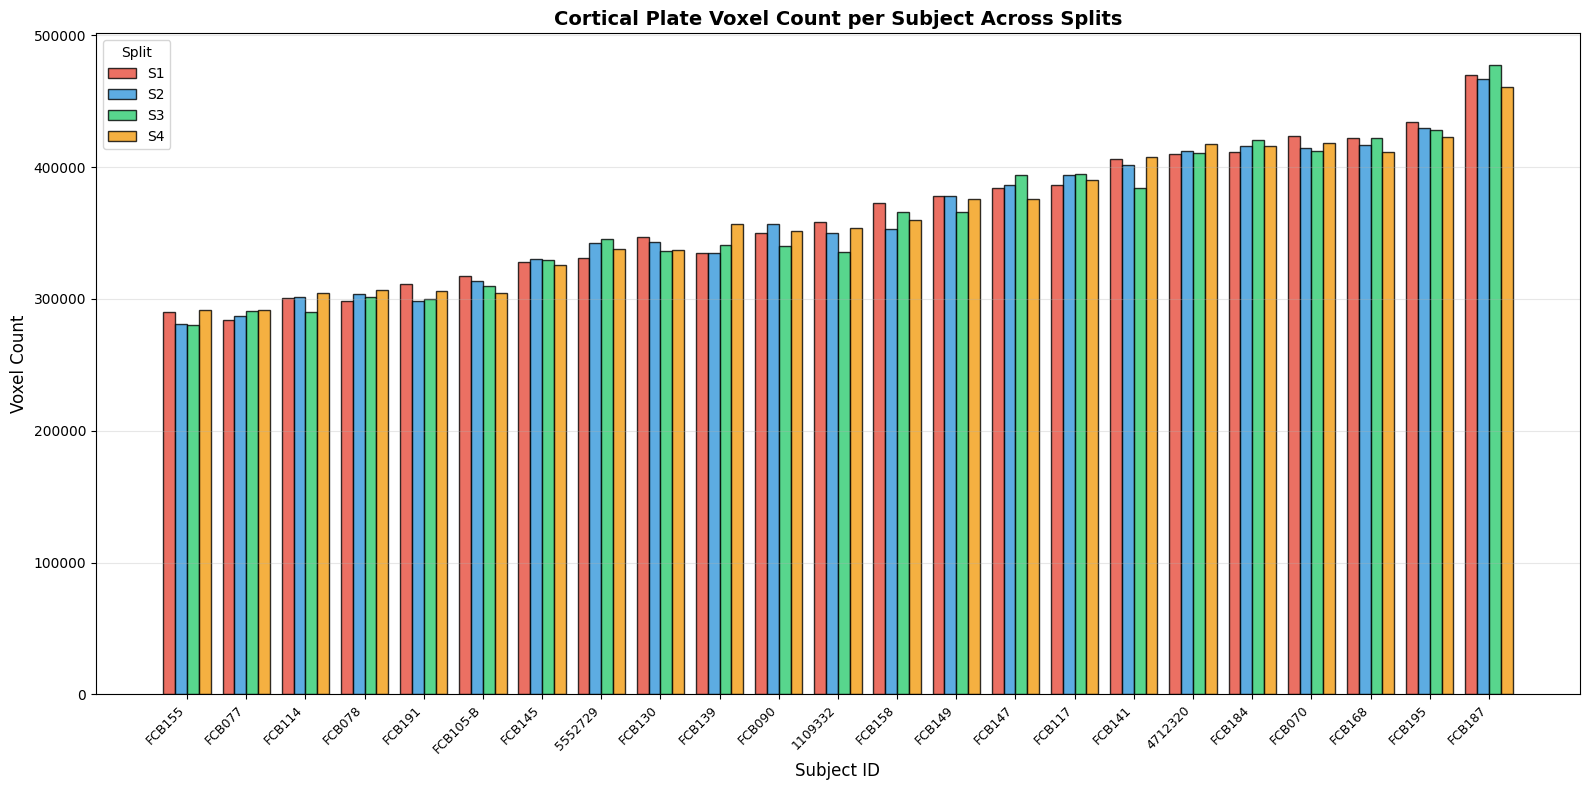

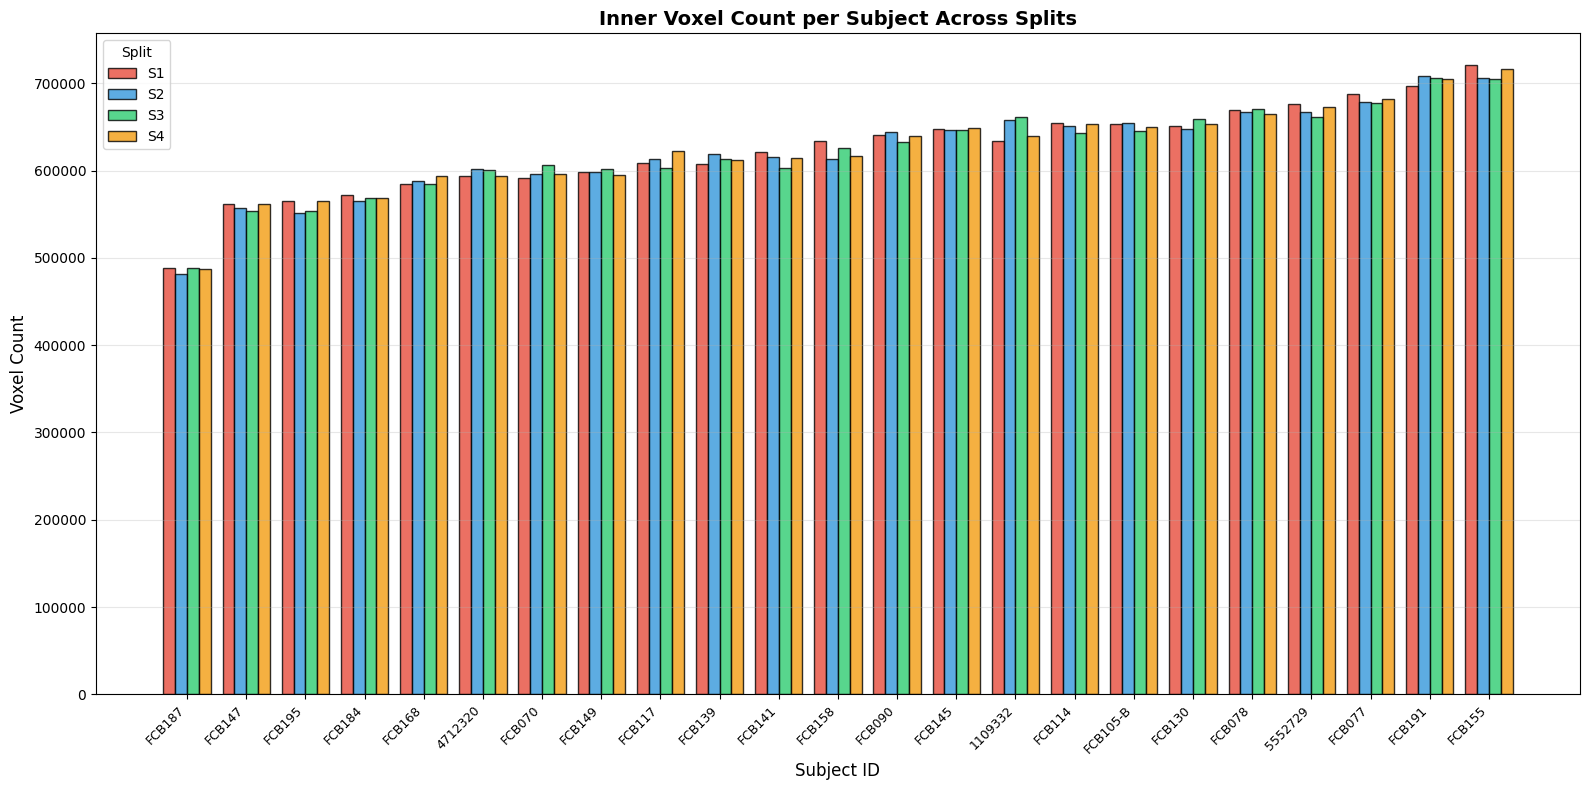

In [26]:
# VOLUME BAR PLOT COMPARISON PER SPLIT (GROUPED)
def plot_per_subject_voxel_counts(quality_df, tissue="sp"):
    """
    Bar plot showing voxel counts per subject for all 4 splits.
    Allows visual comparison of volume consistency within each subject.
    Subjects are ordered by mean voxel count (ascending).

    Parameters:
    -----------
    quality_df : pd.DataFrame
        Long-format dataframe
    tissue : str
        'sp' for subplate, 'cp' for cortical plate, 'inner' for inner tissue
    """
    tissue_names = {"sp": "Subplate", "cp": "Cortical Plate", "inner": "Inner"}
    col_name = f"{tissue}_volume_voxels"
    tissue_name = tissue_names.get(tissue, tissue)

    subjects = get_unique_subjects(quality_df)
    splits = get_available_splits(quality_df)
    colors = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12"]

    # Calculate mean voxel count per subject for ordering
    subject_means = {}
    for (subj_id, ses_id) in subjects:
        vals = []
        for split in splits:
            row = get_split_data(quality_df, subj_id, ses_id, split)
            if row is not None and col_name in row.index and pd.notna(row[col_name]):
                vals.append(row[col_name])
        subject_means[(subj_id, ses_id)] = np.mean(vals) if vals else 0

    # Sort subjects by mean voxel count (ascending)
    subjects_sorted = sorted(subjects, key=lambda s: subject_means[s])

    fig, ax = plt.subplots(figsize=(16, 8))

    x = np.arange(len(subjects_sorted))
    width = 0.2

    for i, split in enumerate(splits):
        values = []
        for (subj_id, ses_id) in subjects_sorted:
            row = get_split_data(quality_df, subj_id, ses_id, split)
            if row is not None and col_name in row.index:
                values.append(row[col_name])
            else:
                values.append(np.nan)

        offset = (i - 1.5) * width
        ax.bar(
            x + offset,
            values,
            width,
            label=split,
            color=colors[i],
            alpha=0.8,
            edgecolor="black",
        )

    ax.set_xticks(x)
    ax.set_xticklabels(
        [str(s) for s, _ in subjects_sorted], rotation=45, ha="right", fontsize=9
    )
    ax.set_xlabel("Subject ID", fontsize=12)
    ax.set_ylabel("Voxel Count", fontsize=12)
    ax.set_title(
        f"{tissue_name} Voxel Count per Subject Across Splits",
        fontsize=14,
        fontweight="bold",
    )
    ax.legend(title="Split", loc="upper left")
    ax.grid(True, alpha=0.3, axis="y")

    plt.tight_layout()
    return fig

def plot_per_subject_native_volume(quality_df, tissue="sp"):
    """
    Bar plot showing native volumes per subject for all splits.
    Allows visual comparison of volume consistency within each subject.
    Subjects are ordered by mean native volume (ascending).

    Parameters:
    -----------
    quality_df : pd.DataFrame
        Long-format dataframe
    tissue : str
        'sp' for subplate, 'cp' for cortical plate, 'inner' for inner tissue
    """
    tissue_names = {"sp": "Subplate", "cp": "Cortical Plate", "inner": "Inner"}
    col_name = f"native_vol_{tissue}"
    tissue_name = tissue_names.get(tissue, tissue)

    subjects = get_unique_subjects(quality_df)
    splits = get_available_splits(quality_df)
    colors = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12"]

    # Calculate mean native volume per subject for ordering
    subject_means = {}
    for (subj_id, ses_id) in subjects:
        vals = []
        for split in splits:
            row = get_split_data(quality_df, subj_id, ses_id, split)
            if row is not None and col_name in row.index and pd.notna(row[col_name]):
                vals.append(row[col_name])
        subject_means[(subj_id, ses_id)] = np.mean(vals) if vals else 0

    # Sort subjects by mean native volume (ascending)
    subjects_sorted = sorted(subjects, key=lambda s: subject_means[s])

    fig, ax = plt.subplots(figsize=(16, 8))

    x = np.arange(len(subjects_sorted))
    width = 0.2

    for i, split in enumerate(splits):
        values = []
        for (subj_id, ses_id) in subjects_sorted:
            row = get_split_data(quality_df, subj_id, ses_id, split)
            if row is not None and col_name in row.index:
                # Convert mm³ to cm³
                values.append(row[col_name] / 1000)
            else:
                values.append(np.nan)

        offset = (i - 1.5) * width
        ax.bar(
            x + offset,
            values,
            width,
            label=split,
            color=colors[i],
            alpha=0.8,
            edgecolor="black",
        )

    ax.set_xticks(x)
    ax.set_xticklabels(
        [str(s) for s, _ in subjects_sorted], rotation=45, ha="right", fontsize=9
    )
    ax.set_xlabel("Subject ID", fontsize=12)
    ax.set_ylabel("Native Volume (cm³)", fontsize=12)
    ax.set_title(
        f"{tissue_name} Native Volume per Subject Across Splits",
        fontsize=14,
        fontweight="bold",
    )
    ax.legend(title="Split", loc="upper left")
    ax.grid(True, alpha=0.3, axis="y")

    plt.tight_layout()
    return fig


## NATIVE VOLUMES
print("=" * 60)
print(" NATIVE VOLUMES")
print("=" * 60)

# Plot for Subplate
fig = plot_per_subject_native_volume(quality_df, tissue="sp")
plt.show()

# Plot for Cortical Plate
fig = plot_per_subject_native_volume(quality_df, tissue="cp")
plt.show()

# Plot for Inner tissue
fig = plot_per_subject_native_volume(quality_df, tissue="inner")
plt.show()

# Voxel counts
print("=" * 60)
print(" VOXEL COUNTS ")
print("=" * 60)

# Plot for Subplate
fig = plot_per_subject_voxel_counts(quality_df, tissue="sp")
plt.show()

# Plot for Cortical Plate
fig = plot_per_subject_voxel_counts(quality_df, tissue="cp")
plt.show()

# Plot for Inner tissue
fig = plot_per_subject_voxel_counts(quality_df, tissue="inner")
plt.show()

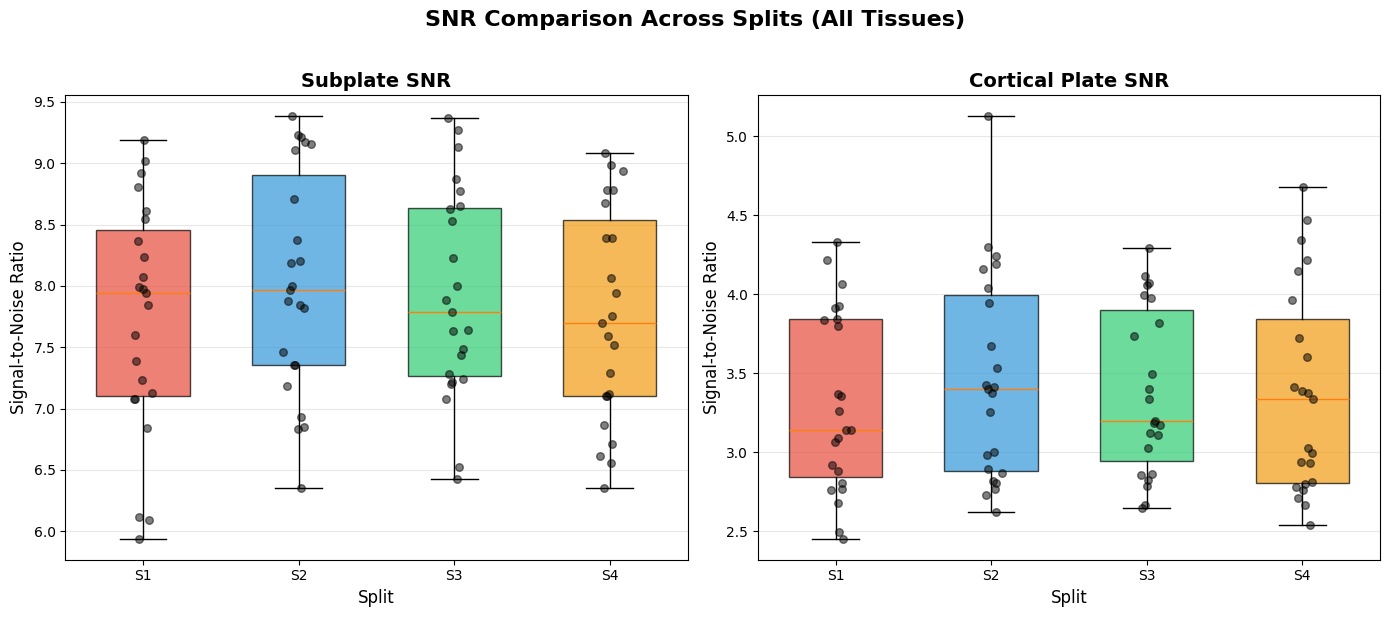

In [8]:
# SNR PLOT
def plot_snr_by_split(quality_df):
    """
    Box plot showing SNR per split for each tissue type.
    Now includes all three tissues: Subplate, Cortical Plate, and Inner.

    Uses long-format quality_df with columns: snr_subplate, snr_cortical_plate, snr_inner
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    splits = get_available_splits(quality_df)
    colors = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12"]

    tissue_configs = [
        ("snr_subplate", "Subplate SNR", axes[0]),
        ("snr_cortical_plate", "Cortical Plate SNR", axes[1]),
    ]

    for col_name, title, ax in tissue_configs:
        # Collect data for box plots
        split_data = []
        for split in splits:
            values = get_column_by_split(quality_df, col_name, split).dropna().values
            split_data.append(values)

        if any(len(d) > 0 for d in split_data):
            bp = ax.boxplot(
                split_data, tick_labels=splits, patch_artist=True, widths=0.6
            )
            for patch, color in zip(bp["boxes"], colors[: len(splits)]):
                patch.set_facecolor(color)
                patch.set_alpha(0.7)

            # Add scatter points
            for i, d in enumerate(split_data):
                if len(d) > 0:
                    x = np.random.normal(i + 1, 0.04, size=len(d))
                    ax.scatter(x, d, alpha=0.5, s=30, color="black", zorder=3)

        ax.set_ylabel("Signal-to-Noise Ratio", fontsize=12)
        ax.set_xlabel("Split", fontsize=12)
        ax.set_title(title, fontsize=14, fontweight="bold")
        ax.grid(True, alpha=0.3, axis="y")

    plt.suptitle(
        "SNR Comparison Across Splits (All Tissues)",
        fontsize=16,
        fontweight="bold",
        y=1.02,
    )
    plt.tight_layout()
    return fig


fig = plot_snr_by_split(quality_df)
plt.show()

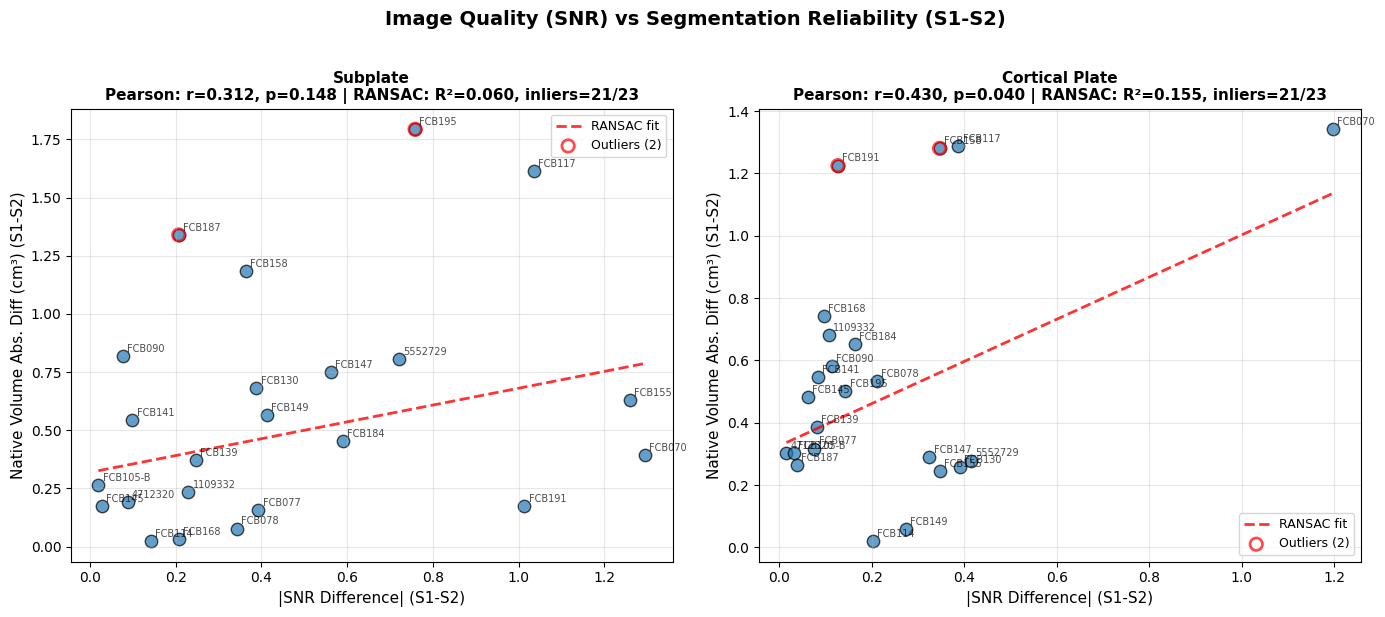

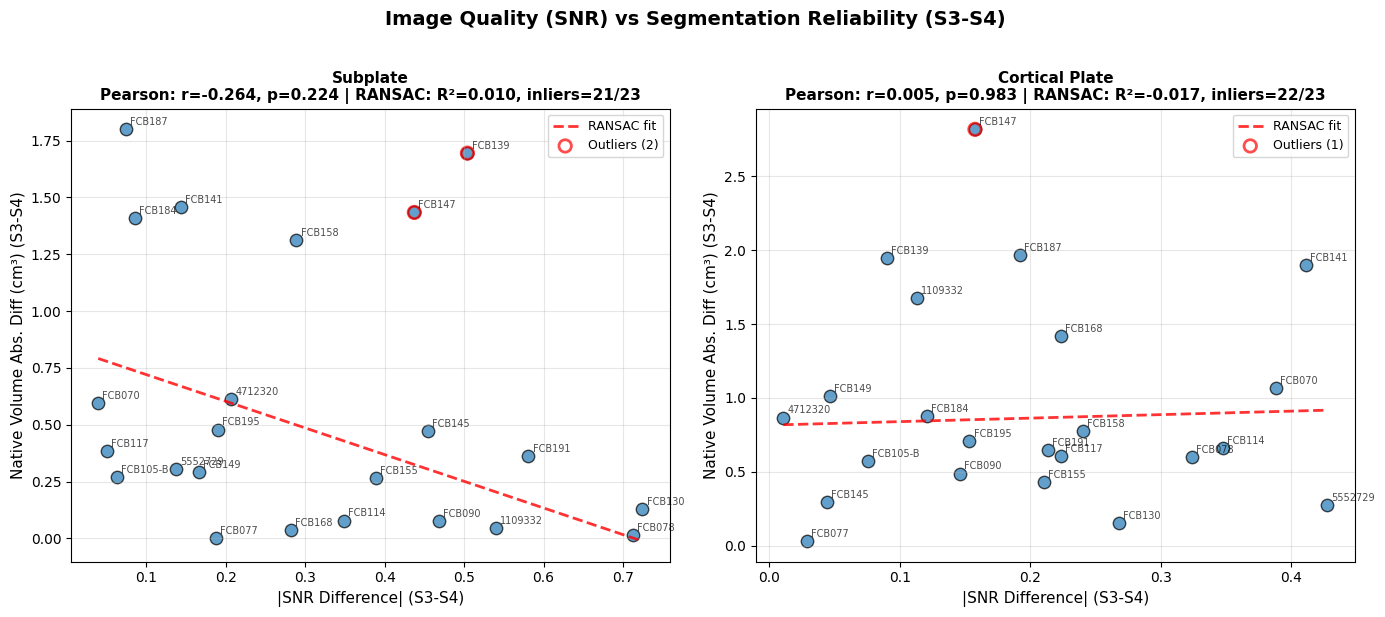

In [ ]:
# SNR VS NATIVE VOLUME COMPARISON (ABSOLUTE DIFFERENCE)
from sklearn.linear_model import RANSACRegressor, LinearRegression


def plot_snr_volume_correlation(quality_df, split_pair=("S1", "S2")):
    """
    Scatter plots showing correlation between SNR difference and absolute native volume difference.
    Uses RANSAC robust linear regression.
    """
    split1, split2 = split_pair
    pair_name = f"{split1}-{split2}"

    tissues = [
        ("snr_subplate", "native_vol_sp", "Subplate"),
        ("snr_cortical_plate", "native_vol_cp", "Cortical Plate"),
    ]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for ax, (snr_col, vol_col, tissue_name) in zip(axes, tissues):
        # Compute SNR difference (absolute)
        snr_diff_df = _compute_split_pair_diff(
            quality_df, snr_col, split1, split2, relative=False
        )
        snr_diff_df = snr_diff_df.rename(columns={"diff": "snr_diff"})

        # Compute native volume absolute difference (in mm³, will convert to cm³)
        vol_diff_df = _compute_split_pair_diff(
            quality_df, vol_col, split1, split2, relative=False
        )
        vol_diff_df = vol_diff_df.rename(columns={"diff": "vol_absdiff"})

        # Merge on subject_id AND session_id
        merged = snr_diff_df[["subject_id", "session_id", "label", "snr_diff"]].merge(
            vol_diff_df[["subject_id", "session_id", "vol_absdiff"]],
            on=["subject_id", "session_id"],
        )

        if len(merged) < 3:
            ax.text(
                0.5,
                0.5,
                f"Insufficient data\n(N={len(merged)})",
                ha="center",
                va="center",
                transform=ax.transAxes,
                fontsize=12,
            )
            ax.set_title(f"{tissue_name}: {pair_name}")
            continue

        x = merged["snr_diff"].values
        y = merged["vol_absdiff"].values / 1000  # Convert mm³ to cm³

        ax.scatter(x, y, s=80, alpha=0.7, edgecolors="black")

        # Add subject labels
        for _, row in merged.iterrows():
            ax.annotate(
                row["label"][:8],
                (row["snr_diff"], row["vol_absdiff"] / 1000),
                fontsize=7,
                alpha=0.7,
                xytext=(3, 3),
                textcoords="offset points",
            )

        # Pearson correlation (on original data)
        r, p = stats.pearsonr(x, y)

        # RANSAC robust linear regression
        X_reshaped = x.reshape(-1, 1)

        ransac = RANSACRegressor(
            residual_threshold= np.std(y) * 1.5,
            min_samples=0.5,  # Use at least 50% of data for fitting
            random_state=42,
        )
        ransac.fit(X_reshaped, y)

        # Get RANSAC statistics
        inlier_mask = ransac.inlier_mask_
        n_inliers = np.sum(inlier_mask)
        r2_score = ransac.score(X_reshaped, y)

        # Plot RANSAC regression line
        x_line = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
        y_line = ransac.predict(x_line)
        ax.plot(x_line, y_line, "r--", alpha=0.8, linewidth=2, label="RANSAC fit")

        # # SIMPLE LINEAR REGRESSION <=========================================
        # z = np.polyfit(x, y, 1)
        # p_line = np.poly1d(z)
        # ax.plot(
        #     x_line.flatten(),
        #     p_line(x_line.flatten()),
        #     "b-",
        #     alpha=0.6,
        #     linewidth=2,
        #     label="OLS fit",
        # )

        # Mark outliers differently
        outlier_mask = ~inlier_mask
        if np.any(outlier_mask):
            ax.scatter(
                x[outlier_mask],
                y[outlier_mask],
                s=80,
                alpha=0.7,
                edgecolors="red",
                linewidths=2,
                facecolors="none",
                label=f"Outliers ({np.sum(outlier_mask)})",
            )

        ax.set_xlabel(f"|SNR Difference| ({pair_name})", fontsize=11)
        ax.set_ylabel(f"Native Volume Abs. Diff (cm³) ({pair_name})", fontsize=11)
        ax.set_title(
            f"{tissue_name}\nPearson: r={r:.3f}, p={p:.3f} | RANSAC: R²={r2_score:.3f}, inliers={n_inliers}/{len(x)}",
            fontsize=11,
            fontweight="bold",
        )
        ax.grid(True, alpha=0.3)
        ax.legend(loc="best", fontsize=9)

    plt.suptitle(
        f"Image Quality (SNR) vs Segmentation Reliability ({pair_name})",
        fontsize=14,
        fontweight="bold",
        y=1.02,
    )
    plt.tight_layout()
    return fig


# Plot for S1-S2 (Independent Pair 1)
fig = plot_snr_volume_correlation(quality_df, split_pair=("S1", "S2"))
plt.show()

# Plot for S3-S4 (Independent Pair 2)
fig = plot_snr_volume_correlation(quality_df, split_pair=("S3", "S4"))
plt.show()


Processing S1-S2

Volume SP diff subjects: 23
Volume CP diff subjects: 23
SNR diff subjects: 23
After merging volume and SNR diffs: 23 subjects
After merging with infodump: 23 subjects
Complete cases for correlation: 23

--- Diagnostic Table for S1-S2 ---
subject_id                              session_id  vol_sp_absdiff  vol_cp_absdiff  snr_diff  qa_diff_S1S2  QA12_mean    GA
   1109332      MR-EI_Fetal_Body-26810110-20230404           0.234           0.680     0.230          0.08       0.54 27.00
    FCB145 2019.03.20-032Y-MR_EI_Fetal_Neuro-29197           0.173           0.482     0.028          0.17       0.83 27.71
    FCB149 2019.04.11-030Y-MR_EI_Fetal_Neuro-29205           0.564           0.059     0.412          0.17       0.92 28.86
    FCB195     MR-EI_Fetal_Neuro-26792482-20230322           1.793           0.501     0.759          0.00       0.67 30.00
    FCB187   2022.06.10-MR-EI_Fetal_Neuro-26465115           1.339           0.263     0.207          0.09       0.88 32.71

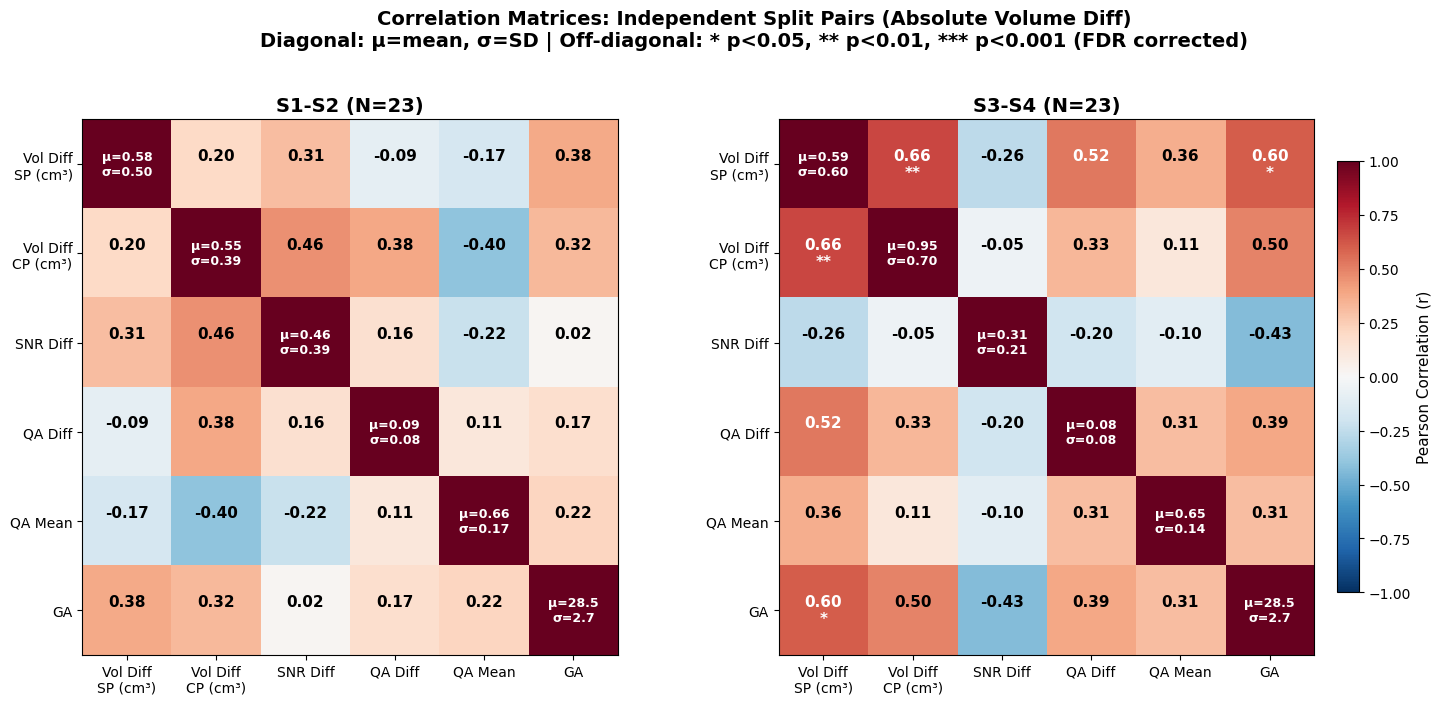

In [16]:
# === CELL 9: Correlation Matrix Heatmaps (S1-S2 and S3-S4) ===
from statsmodels.stats.multitest import multipletests


def plot_correlation_matrices(quality_df, infodump_df, print_diagnostics=True):
    """
    Create two correlation matrix heatmaps - one for S1-S2 and one for S3-S4.

    Each shows relationships between:
    - Native volume absolute difference (SP and CP) in cm³
    - GA (Gestational Age)
    - QA difference (between splits)
    - QA mean (overall reconstruction quality)
    - SNR difference

    Uses long-format quality_df and computes differences on the fly.
    P-values are corrected for multiple comparisons using FDR (Benjamini-Hochberg).

    Diagonal cells show mean ± SD for each variable instead of r=1.00.
    """
    # Prepare infodump data
    infodump = infodump_df.copy()
    infodump["subject_id"] = infodump["subject_id"].astype(str)
    infodump["session_id"] = infodump["session_id"].astype(str)

    # Calculate QA differences
    if "QA_S1" in infodump.columns and "QA_S2" in infodump.columns:
        infodump["qa_diff_S1S2"] = abs(infodump["QA_S1"] - infodump["QA_S2"])
    if "QA_S3" in infodump.columns and "QA_S4" in infodump.columns:
        infodump["qa_diff_S3S4"] = abs(infodump["QA_S3"] - infodump["QA_S4"])

    # QA means should already be in the data as QA12_mean and QA34_mean
    if "QA12_mean" not in infodump.columns and "QA_S1" in infodump.columns:
        infodump["QA12_mean"] = (infodump["QA_S1"] + infodump["QA_S2"]) / 2
    if "QA34_mean" not in infodump.columns and "QA_S3" in infodump.columns:
        infodump["QA34_mean"] = (infodump["QA_S3"] + infodump["QA_S4"]) / 2

    # Build analysis dataframes for each split pair
    split_configs = {
        "S1-S2": {
            "splits": ("S1", "S2"),
            "qa_diff_col": "qa_diff_S1S2",
            "qa_mean_col": "QA12_mean",
        },
        "S3-S4": {
            "splits": ("S3", "S4"),
            "qa_diff_col": "qa_diff_S3S4",
            "qa_mean_col": "QA34_mean",
        },
    }

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    for ax_idx, (pair_name, config) in enumerate(split_configs.items()):
        ax = axes[ax_idx]
        split1, split2 = config["splits"]

        if print_diagnostics:
            print(f"\n{'='*60}")
            print(f"Processing {pair_name}")
            print(f"{'='*60}")

        # Compute native volume ABSOLUTE differences (then convert to cm³)
        vol_sp_diff = _compute_split_pair_diff(
            quality_df, "native_vol_sp", split1, split2, relative=False
        )
        vol_sp_diff["vol_sp_absdiff"] = vol_sp_diff["diff"] / 1000  # mm³ to cm³
        vol_sp_diff["subject_id"] = vol_sp_diff["subject_id"].astype(str)
        vol_sp_diff["session_id"] = vol_sp_diff["session_id"].astype(str)

        vol_cp_diff = _compute_split_pair_diff(
            quality_df, "native_vol_cp", split1, split2, relative=False
        )
        vol_cp_diff["vol_cp_absdiff"] = vol_cp_diff["diff"] / 1000  # mm³ to cm³
        vol_cp_diff["subject_id"] = vol_cp_diff["subject_id"].astype(str)
        vol_cp_diff["session_id"] = vol_cp_diff["session_id"].astype(str)

        # Compute SNR differences (absolute)
        snr_diff = _compute_split_pair_diff(
            quality_df, "snr_subplate", split1, split2, relative=False
        )
        snr_diff = snr_diff.rename(columns={"diff": "snr_diff"})
        snr_diff["subject_id"] = snr_diff["subject_id"].astype(str)
        snr_diff["session_id"] = snr_diff["session_id"].astype(str)

        if print_diagnostics:
            print(f"\nVolume SP diff subjects: {len(vol_sp_diff)}")
            print(f"Volume CP diff subjects: {len(vol_cp_diff)}")
            print(f"SNR diff subjects: {len(snr_diff)}")

        # Merge all data on BOTH subject_id AND session_id
        merged = (
            vol_sp_diff[["subject_id", "session_id", "vol_sp_absdiff"]]
            .merge(
                vol_cp_diff[["subject_id", "session_id", "vol_cp_absdiff"]],
                on=["subject_id", "session_id"],
                how="inner",
            )
            .merge(
                snr_diff[["subject_id", "session_id", "snr_diff"]],
                on=["subject_id", "session_id"],
                how="inner",
            )
        )

        if print_diagnostics:
            print(f"After merging volume and SNR diffs: {len(merged)} subjects")

        # Add infodump columns - merge on BOTH subject_id AND session_id
        cols_to_add = ["subject_id", "session_id", "GA"]
        if config["qa_diff_col"] in infodump.columns:
            cols_to_add.append(config["qa_diff_col"])
        if config["qa_mean_col"] in infodump.columns:
            cols_to_add.append(config["qa_mean_col"])

        merged = merged.merge(
            infodump[cols_to_add].drop_duplicates(),
            on=["subject_id", "session_id"],
            how="left",
        )

        if print_diagnostics:
            print(f"After merging with infodump: {len(merged)} subjects")

        # Define columns and labels for correlation matrix
        columns = ["vol_sp_absdiff", "vol_cp_absdiff", "snr_diff"]
        labels = ["Vol Diff\nSP (cm³)", "Vol Diff\nCP (cm³)", "SNR Diff"]

        if config["qa_diff_col"] in merged.columns:
            columns.append(config["qa_diff_col"])
            labels.append("QA Diff")

        if config["qa_mean_col"] in merged.columns:
            columns.append(config["qa_mean_col"])
            labels.append("QA Mean")

        if "GA" in merged.columns:
            columns.append("GA")
            labels.append("GA")

        # Filter to available columns
        available_cols = [c for c in columns if c in merged.columns]
        available_labels = [
            labels[i] for i, c in enumerate(columns) if c in merged.columns
        ]

        if len(available_cols) < 2:
            ax.text(
                0.5,
                0.5,
                f"Insufficient data for {pair_name}",
                ha="center",
                va="center",
                transform=ax.transAxes,
                fontsize=12,
            )
            ax.set_title(f"{pair_name} Correlation Matrix")
            continue

        # Get complete cases
        corr_data = merged[available_cols].dropna()

        if print_diagnostics:
            print(f"Complete cases for correlation: {len(corr_data)}")
            print(f"\n--- Diagnostic Table for {pair_name} ---")
            display_df = merged[["subject_id", "session_id"] + available_cols].copy()
            display_df = display_df.round(3)
            print(display_df.to_string(index=False))

            # Print descriptive statistics
            print(f"\n--- Descriptive Statistics for {pair_name} ---")
            desc_stats = corr_data.describe().T[["mean", "std", "min", "max"]]
            desc_stats.index = available_labels
            print(desc_stats.round(3).to_string())
            print()

        if len(corr_data) < 3:
            ax.text(
                0.5,
                0.5,
                f"Not enough complete cases\n(N={len(corr_data)})",
                ha="center",
                va="center",
                transform=ax.transAxes,
                fontsize=12,
            )
            ax.set_title(f"{pair_name} Correlation Matrix")
            continue

        # Compute correlation matrix
        corr_matrix = corr_data.corr(method="pearson")

        # Compute mean and std for each variable (for diagonal display)
        var_means = corr_data.mean()
        var_stds = corr_data.std()

        # Compute p-values and collect for FDR correction
        n_vars = len(available_cols)
        p_matrix = np.zeros((n_vars, n_vars))
        p_values_list = []  # For FDR correction
        p_indices = []  # Track which cells each p-value belongs to

        for i in range(n_vars):
            for j in range(n_vars):
                if i == j:
                    p_matrix[i, j] = 1.0  # Diagonal
                elif i < j:  # Only compute upper triangle
                    _, p = stats.pearsonr(
                        corr_data[available_cols[i]], corr_data[available_cols[j]]
                    )
                    p_matrix[i, j] = p
                    p_matrix[j, i] = p  # Symmetric
                    p_values_list.append(p)
                    p_indices.append((i, j))

        # Apply FDR correction (Benjamini-Hochberg)
        if len(p_values_list) > 0:
            _, p_corrected, _, _ = multipletests(p_values_list, method="fdr_bh")

            # Create corrected p-value matrix
            p_corrected_matrix = np.ones((n_vars, n_vars))
            for idx, (i, j) in enumerate(p_indices):
                p_corrected_matrix[i, j] = p_corrected[idx]
                p_corrected_matrix[j, i] = p_corrected[idx]
        else:
            p_corrected_matrix = p_matrix.copy()

        if print_diagnostics:
            print(f"--- Raw p-values (upper triangle) ---")
            for idx, (i, j) in enumerate(p_indices):
                print(
                    f"  {available_labels[i]} vs {available_labels[j]}: p={p_values_list[idx]:.4f} -> FDR corrected: {p_corrected[idx]:.4f}"
                )
            print()

        # Plot heatmap
        im = ax.imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1, aspect="equal")

        # Set ticks
        ax.set_xticks(range(len(available_labels)))
        ax.set_yticks(range(len(available_labels)))
        ax.set_xticklabels(available_labels, fontsize=10)
        ax.set_yticklabels(available_labels, fontsize=10)

        # Add correlation values and significance stars (using FDR-corrected p-values)
        # Diagonal cells show mean ± SD instead of r=1.00
        for i in range(n_vars):
            for j in range(n_vars):
                if i == j:
                    # Diagonal: show mean ± SD
                    mean_val = var_means[available_cols[i]]
                    std_val = var_stds[available_cols[i]]

                    # Format based on magnitude (avoid overly long numbers)
                    if abs(mean_val) >= 100:
                        text = f"μ={mean_val:.0f}\nσ={std_val:.0f}"
                    elif abs(mean_val) >= 10:
                        text = f"μ={mean_val:.1f}\nσ={std_val:.1f}"
                    else:
                        text = f"μ={mean_val:.2f}\nσ={std_val:.2f}"

                    # Diagonal is white (r=1), so use black text
                    ax.text(
                        j,
                        i,
                        text,
                        ha="center",
                        va="center",
                        color="white",
                        fontsize=9,
                        fontweight="bold",
                    )
                else:
                    # Off-diagonal: show correlation and significance
                    r = corr_matrix.iloc[i, j]
                    p_corr = p_corrected_matrix[i, j]

                    # Significance stars based on FDR-corrected p-values
                    if p_corr < 0.001:
                        sig = "***"
                    elif p_corr < 0.01:
                        sig = "**"
                    elif p_corr < 0.05:
                        sig = "*"
                    else:
                        sig = ""

                    text_color = "white" if abs(r) > 0.5 else "black"
                    ax.text(
                        j,
                        i,
                        f"{r:.2f}\n{sig}",
                        ha="center",
                        va="center",
                        color=text_color,
                        fontsize=11,
                        fontweight="bold",
                    )

        ax.set_title(
            f"{pair_name} (N={len(corr_data)})", fontsize=14, fontweight="bold"
        )

    # Add colorbar manually to avoid tight_layout issues
    cbar = fig.colorbar(
        im, ax=axes.ravel().tolist(), fraction=0.046, pad=0.04, shrink=0.8
    )
    cbar.set_label("Pearson Correlation (r)", fontsize=11)

    plt.suptitle(
        "Correlation Matrices: Independent Split Pairs (Absolute Volume Diff)\n"
        "Diagonal: μ=mean, σ=SD | Off-diagonal: * p<0.05, ** p<0.01, *** p<0.001 (FDR corrected)",
        fontsize=14,
        fontweight="bold",
        y=1.02,
    )

    # Use constrained_layout or manual adjustment instead of tight_layout
    fig.subplots_adjust(left=0.08, right=0.85, top=0.88, bottom=0.08, wspace=0.3)

    return fig


fig = plot_correlation_matrices(quality_df, infodump_df, print_diagnostics=True)
plt.show()

In [ ]:
# Check if S3-S4 has systematically different quality
print("S1-S2 QA mean:", infodump_df["QA12_mean"].mean())
print("S3-S4 QA mean:", infodump_df["QA34_mean"].mean())
print(
    "\nS1-S2 QA diff mean:",
    (
        infodump_df["qa_diff_S1S2"].mean()
        if "qa_diff_S1S2" in infodump_df.columns
        else abs(infodump_df["QA_S1"] - infodump_df["QA_S2"]).mean()
    ),
)
print(
    "S3-S4 QA diff mean:",
    (
        infodump_df["qa_diff_S3S4"].mean()
        if "qa_diff_S3S4" in infodump_df.columns
        else abs(infodump_df["QA_S3"] - infodump_df["QA_S4"]).mean()
    ),
)

# # TODO: Finish t his plot
# def plot_per_subject_cross_split_abs_QA(infodump_df):
    
#     fig, ax = plt.subplots(figsize=(14, 8))

#     x = np.arange(len())

S1-S2 QA mean: 0.6630434782608695
S3-S4 QA mean: 0.6478260869565219

S1-S2 QA diff mean: 0.09391304347826088
S3-S4 QA diff mean: 0.07739130434782608


In [12]:
## IRRELEVANT: PLEASE IGNORE TODO: rEMOVE LATER
def statistical_model_comparison(df):
    """Perform statistical tests comparing models."""
    print("\n" + "=" * 80)
    print("STATISTICAL COMPARISON BETWEEN MODELS")
    print("=" * 80)

    comparisons = [
        ("SP Model - Subplate", "SP Model - Cortical Plate"),
        ("SP Model - Subplate", "5-Label Model - Cortical Plate"),
        ("SP Model - Cortical Plate", "5-Label Model - Cortical Plate"),
    ]

    print("\nPairwise Wilcoxon signed-rank tests on Dice scores:")
    print("-" * 60)

    for model_a, model_b in comparisons:
        df_a = df[df["model"] == model_a].groupby("subject_id")["dice"].mean()
        df_b = df[df["model"] == model_b].groupby("subject_id")["dice"].mean()

        common_subjects = df_a.index.intersection(df_b.index)
        data_a = df_a.loc[common_subjects].values
        data_b = df_b.loc[common_subjects].values

        stat, p_value = stats.wilcoxon(data_a, data_b)
        mean_diff = np.mean(data_a) - np.mean(data_b)

        significance = (
            "***"
            if p_value < 0.001
            else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
        )

        print(f"\n{model_a[:25]:25s} vs {model_b[:25]:25s}")
        print(f"  Mean difference: {mean_diff:+.4f}")
        print(f"  Wilcoxon p-value: {p_value:.4f} {significance}")
        print(f"  N subjects: {len(common_subjects)}")


statistical_model_comparison(reliability_df)


STATISTICAL COMPARISON BETWEEN MODELS

Pairwise Wilcoxon signed-rank tests on Dice scores:
------------------------------------------------------------

SP Model - Subplate       vs SP Model - Cortical Plate
  Mean difference: +0.0433
  Wilcoxon p-value: 0.0000 ***
  N subjects: 23

SP Model - Subplate       vs 5-Label Model - Cortical 
  Mean difference: +0.0669
  Wilcoxon p-value: 0.0000 ***
  N subjects: 23

SP Model - Cortical Plate vs 5-Label Model - Cortical 
  Mean difference: +0.0237
  Wilcoxon p-value: 0.0000 ***
  N subjects: 23


In [41]:
def print_final_summary(reliability_df, quality_df, infodump_df):
    """Print a final summary of key findings."""
    print("\n" + "=" * 80)
    print("FINAL SUMMARY REPORT")
    print("=" * 80)

    n_subjects = reliability_df["subject_id"].nunique()
    n_quality = len(quality_df)

    print(
        f"\nDataset: {n_subjects} subjects with reliability metrics, {n_quality} with quality metrics"
    )

    # GA range
    if "GA" in infodump_df.columns:
        ga_min = infodump_df["GA"].min()
        ga_max = infodump_df["GA"].max()
        print(f"Gestational Age range: {ga_min:.1f} - {ga_max:.1f} weeks")

    print("\n--- RELIABILITY RANKING (by mean Dice) ---")
    model_means = (
        reliability_df.groupby("model")["dice"].mean().sort_values(ascending=False)
    )
    for i, (model, mean_dice) in enumerate(model_means.items(), 1):
        std = reliability_df[reliability_df["model"] == model]["dice"].std()
        print(f"  {i}. {model}: {mean_dice:.4f} ± {std:.4f}")

    print("\n--- RELIABILITY RANKING (by mean Voxel Rel. Diff - lower is better) ---")
    model_vox = (
        reliability_df.groupby("model")["relative_diff"]
        .mean()
        .sort_values(ascending=True)
    )
    for i, (model, mean_vox) in enumerate(model_vox.items(), 1):
        std = reliability_df[reliability_df["model"] == model]["relative_diff"].std()
        print(f"  {i}. {model}: {mean_vox:.2f}% ± {std:.2f}%")

    # SNR summary
    if "snr_sp_mean" in quality_df.columns:
        print(f"\n--- SNR SUMMARY ---")
        print(
            f"  Mean SNR (Subplate): {quality_df['snr_sp_mean'].mean():.2f} ± {quality_df['snr_sp_mean'].std():.2f}"
        )
        print(
            f"  Mean SNR (Cortical Plate): {quality_df['snr_cp_mean'].mean():.2f} ± {quality_df['snr_cp_mean'].std():.2f}"
        )

    print("\n" + "=" * 80)


print_final_summary(reliability_df, quality_df, infodump_df)


FINAL SUMMARY REPORT

Dataset: 23 subjects with reliability metrics, 92 with quality metrics
Gestational Age range: 22.0 - 32.7 weeks

--- RELIABILITY RANKING (by mean Dice) ---
  1. SP Model - Subplate: 0.8533 ± 0.0621
  2. SP Model - Cortical Plate: 0.8101 ± 0.0869
  3. 5-Label Model - Cortical Plate: 0.7864 ± 0.0932

--- RELIABILITY RANKING (by mean Voxel Rel. Diff - lower is better) ---
  1. SP Model - Subplate: 1.50% ± 1.28%
  2. SP Model - Cortical Plate: 2.06% ± 1.49%
  3. 5-Label Model - Cortical Plate: 2.70% ± 2.07%

